<a href="https://www.kaggle.com/code/monicaneli/industrial-machine-downtime-prediction?scriptVersionId=301474852" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Industrial Machine Downtime Prediction with Data Science
**Predictive Maintenance in Industrial Manufacturing**

In the manufacturing of high-precision metal components used in aerospace, automotive, and medical device applications, there are three different machines, producing components of various sizes. Minimizing machine downtime is crucial for meeting production deadlines.

The team aims to adopt a data-driven approach for predicting machine downtime, enabling proactive maintenance planning instead of reacting to machine failures. To support this initiative, the company has been collecting operational data over the past year, for when each machine was down.

This analysis represents the first step in utilizing this data for improving machine reliability and optimizing maintenance strategies and schedules.


## Executive Summary

This analysis demonstrated that predictive maintenance using machine learning can effectively anticipate downtime, with the XGBoost model achieving 99.9% accuracy. Key factors influencing downtime include Hydraulic Pressure, Torque, and Cutting, highlighting areas for improved monitoring. While the dataset provided a strong foundation, further enhancements through data preprocessing, sensor reliability improvements, and real-time monitoring would refine predictive capabilities and optimize maintenance strategies.

### Objectives

- EDA: Identify patterns and main causes of machine failures to enable proactive measures to minimize interruptions.
- Machine Learning Model: Enable proactive maintenance through predictive maintenance, rather than reacting to machine failures.
- Simulation considering financial factors and economic viability for predictive maintenance.
- Monitoring: Define strategies and next steps for continuous monitoring and improvement.

### Main Findings

**1. Data Collection and Quality**

- Good overall data quality: No duplicates and low missingness. Correlations in missingness suggest shared sensors or operational factors (e.g., sensor degradation).
- Uneven data collection across time and machines: Further investigation into data gaps, data collection strategies, frequency variations is needed to validate trends and to fully assess data quality and potential biases.
- Sensor Reliability and Measurement Anomalies: Potential measurement errors detected, including negative values, extreme highs, and near-zero readings. Spindle Vibration, Tool Vibration, and Torque frequently show near-zero values, for both during normal operations and during failure, raising concerns about sensor reliability. Anomalies could stem from cyclic machine behavior, such as pauses in rotation or inactive components.



**2. Downtime Rate & Trends**

- High Downtime Frequency: Downtime occurred roughly every week, with only two weeks showing no incidents. Saturdays had a 100% downtime occurrence rate, while Wednesdays had the lowest (84%).

- Peaks in readings and downtime occurrences are proportional, suggesting intentional monitoring to preempt downtime. Both metrics rose during the longest and continuous monitoring period (Jan 5, 2022 – May 19, 2022).

- Trend Over Time: From February to June, downtime rates averaged 50%, remaining stable yet significant.

- Downtime Comparison: Makino-L1-Unit1-2013 (ShopFloor-L1) & Makino-L3-Unit1-2015 improved over time, ending below 50%. Makino-L2-Unit1-2015 worsened, consistently exceeding 50% later.

**3. Which assembly line has the highest readings of machine downtime?**

- Overall all three machines had 50% downtime rate as median, but the assembly line `ShopFloor-L1` had the higher downtime rate in average.
  
- In addition, the Makino-L1-Unit1-2013 (from assembly line ShopFloor-L1) had the highest 7-day downtime rate rolling averages (54%), the highest total readings (874) and also most 100% downtime days (22).

- However, it was followed closely by Makino-L3-Unit1-2015 (from assembly line ShopFloor-L3, 51%, 818 readings and 19 days with 100% downtime) and Makino-L2-Unit1-2015 (from assembly line ShopFloor-L2, 46%, 808 readings and 17 days with 100% downtime).


**4. Key Factors and Patterns in Downtime Predictions**

- From the EDA Analysis, the Key Downtime Correlations (Confirmed by Statistical Tests) were:

    - Lower Hydraulic Pressure → Strongly linked to downtime (large effect size: 0.65).
    - Lower Torque → Associated with downtime (medium effect size: 0.33).
    - Higher Cutting Force → Contributes to downtime (medium effect size: -0.45).
    - Higher Coolant Temperature & Spindle Speed → Occasionally contribute to downtime (small-to-moderate effect sizes).

- XGBoost outperformed Logistic Regression, achieving a Precision-Recall AUC of 0.991 vs. 0.899 in training and 99.9% accuracy vs. 81.9% in testing.
  
- XGBoost's feature importance identified Hydraulic Pressure as the most impactful feature (40%), followed by Torque and Cutting (≈25% each).

- In contrast, SHAP identifies Torque, Cutting, Coolant Pressure, and Hydraulic Pressure as the most impactful features for predictions.

 

### Key Takeaways & Next Steps
- Downtime remains a critical issue, with 50%+ occurrence rates and high variance across machines.
- Torque, Cutting, Coolant Pressure, and Hydraulic Pressure are key predictors of downtime, warranting further monitoring.
- The XGBoost model demonstrated effectiveness in predicting downtime. Hyperparameter tuning and feature selection could still be applied.
- Sensor reliability concerns must be addressed to improve data accuracy.
- Data collection inconsistencies & missing values need investigation, particularly regarding sensor correlations and operational factors.
- Standardizing data collection and addressing data gaps it is need to improve reliability and avoid bias.
- Predictive maintenance could be further improved by incorporating timestamp data, time-series feature engineering, and anomaly detection to enhance early failure detection.
- The simulation, considering financial factors and economic viability, indicates that based on the 136-day test set and a 99% F1-score XGBoost model, predictive maintenance is financially superior to reactive maintenance under the tested assumptions. 
- More specific recommendations on monitoring and data preprocessing would require deeper business insights.

## The data

The readings represent continuous operational data collected from machines on each shop floor. These readings capture key parameters such as pressure, temperature, torque, and speed, providing insights into machine performance and health.

The company has stored the machine operating data in a single table. Each row in the table corresponds to a single machine's operational reading on a given day. However, no details were provided regarding the data collection process, such as strategies or methodology, which are crucial for assessing data quality.

The data has undergone transformations to enhance analysis, including renaming columns, casting data types, and mapping target class values.


| Feature                              | Description            | Unit                 | Significance |
|--------------------------------------|------------------------|----------------------|-------------|
| Date								   | Date of the reading 	| datetime64           | Enables temporal analysis of maintenance history |
| Machine_ID                           | Unique machine identifier | category          | Enables comparative analysis by machine | 
| Assembly_Line_No                     | Unique assembly line identifier | category | Enables comparative analysis by assembly line | 
| Hydraulic_Pressure                   | Hydraulic system pressure | bar             | Assesses the health of the fluid power system |
| Coolant_Pressure                     | Coolant system pressure | bar             | Assesses the health of the coolant system |
| Air_System_Pressure                   | Air system pressure    | bar             | Evaluates the status of air compression |
| Coolant_Temperature                   | Coolant system temperature | Celsius     | Assesses the health of the coolant system |
| Hydraulic_Oil_Temperature             | Hydraulic oil temperature | Celsius     | Assesses the health of the hydraulic system |
| Spindle_Bearing_Temperature           | Spindle bearing temperature | Celsius  | Assesses the health of the spindle system |
| Spindle_Vibration                     | Spindle vibration level | Micrometers | Evaluates spindle performance |
| Tool_Vibration                        | Tool vibration level    | Micrometers | Evaluates tool performance |
| Spindle_Speed                         | Spindle rotational speed | RPM (Revolutions Per Minute) | Evaluates spindle performance |
| Voltage                               | System voltage          | Volts           | Evaluates electrical performance |
| Torque                                | Torque                 | Newton-meters (Nm) | Evaluates mechanical performance |
| Cutting                               | Cutting force          | Kilonewtons (kN) | Evaluates cutting performance |
| Downtime                              | Operational status      | Boolean         | Distinguishes whether machines are operating normally or experiencing failures ||uipment damage.

In [1]:
# Main imports
import numpy as np
import pandas as pd
from scipy.stats import skew
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.dates as mdates
from datetime import datetime
from dateutil.relativedelta import relativedelta
import scipy.stats as stats
from scipy.stats import shapiro, levene, mannwhitneyu, kruskal, ttest_ind, f_oneway

import itertools
import seaborn as sns
import missingno as msno
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

SEED = 42

# Generate a colorblind-friendly palette with 20 colors
tol_palette = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77", 
    "#CC6677", "#882255", "#AA4499", "#661100", "#6699CC", "#AA4466", 
    "#4477AA", "#DDDDDD", "#000000", "#F0E442", "#D55E00", "#009E73", 
    "#E69F00", "#56B4E9", "#0072B2"
]
palette = tol_palette
custom_palette = {0: palette[6], 1: palette[2]}
sns.set_palette(palette)
sns.set_style("darkgrid")

# Threshold line parameters
threshold_line_kwargs1 = {
    'linewidth': 1,
    'linestyle': '--',
    'color': 'red'
}
threshold_line_kwargs2 = {
    'linewidth': 1,
    'linestyle': '--',
    'color': 'black'
}

def evaluate_column_skewness(dataframe, column, threshold=0.5):
    result = None
    skewness_value = None
    try:
        column_data = dataframe[column].dropna().astype('float64')
        column_skewness = skew(column_data)
    except (RuntimeError, TypeError, NameError):
        column_data = dataframe[column].dropna().astype('float64')
        column_skewness = skew(column_data)
    
    if column_skewness > threshold:
        #return ( f"is Right-skewed (positively skewed) {round(column_skewness, 2)}.")
        result = "Right-skewed"
        skewness_value = round(column_skewness, 2)
    elif column_skewness < -threshold:
        #return( f"is Left-skewed (negatively skewed) {round(column_skewness, 2)}.")
        result = "Left-skewed"
        skewness_value = round(column_skewness, 2)
    else:
        #return( f"is Symmetric (not skewed) {round(column_skewness, 2)}.")
        result = "Symmetric"
        skewness_value = round(column_skewness, 2)

    return (result, skewness_value)

def calc_upper_lower_whiskers(df, column):
    # Calculate the quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Determine the theoretical whisker limits
    lower_whisker_limit = Q1 - 1.5 * IQR
    upper_whisker_limit = Q3 + 1.5 * IQR

    # Find the actual data points within the whisker limits
    lower_whisker = df[column][df[column] >= lower_whisker_limit].min()
    upper_whisker = df[column][df[column] <= upper_whisker_limit].max()

    #print(f"\nLower whisker of {column} {lower_whisker}.")
    #print(f"Upper whisker of {column} {upper_whisker}.")    
    return (round(lower_whisker, 2), round(upper_whisker, 2))


# Function to test normality for each group
def test_normality(data, group_col, target_feature, min_group_size=3):
    results = {}
    for group in data[group_col].unique():
        group_data = data[data[group_col] == group][target_feature]
        
        # Check if the group has at least the minimum required size
        if len(group_data) < min_group_size:
            results[group] = 10 #"Insufficient data (< 3 observations)"
        else:
            # Perform Shapiro-Wilk test
            p_value = shapiro(group_data).pvalue
            results[group] = p_value
    
    return results

# Function to test homogeneity of variance
def test_variance_homogeneity(data, group_col, target_feature, min_group_size=2, significance_level=0.05):
    # Extract groups
    groups = [data[data[group_col] == group][target_feature] for group in data[group_col].unique()]
    
    # Check if all groups have at least the minimum size
    small_groups = [group for group in groups if len(group) < min_group_size]
    
    if small_groups:
        print(f"Warning: {len(small_groups)} group(s) have fewer than {min_group_size} observations. Assuming heterogeneity.")
        return False  
    
    # Perform Levene's test
    p_value = levene(*groups).pvalue
    #print(f"Levene's test p-value: {p_value}")
    return p_value > significance_level 

def get_cleaned_groups(data, group_col, target_col, group1, group2, min_size=1):
    """
    Cleans and prepares groups for statistical testing.

    Parameters:
    - data (pd.DataFrame): The dataset containing the data.
    - group_col (str): The column used to group data.
    - target_col (str): The target column for statistical testing.
    - group1, group2: The values of the group_col to extract.
    - min_size (int): Minimum required size for each group.

    Returns:
    - grp1_cleaned, grp2_cleaned: Cleaned groups as Pandas Series.
    - is_valid (bool): Whether both groups are valid for testing.
    - message (str): Information about the cleaning or issues.
    """
    # Extract groups and drop NaN values
    grp1 = data[data[group_col] == group1][target_col].dropna()
    grp2 = data[data[group_col] == group2][target_col].dropna()

    # Ensure groups are numeric
    if not pd.api.types.is_numeric_dtype(grp1) or not pd.api.types.is_numeric_dtype(grp2):
        return None, None, False, "Non-numeric data in one or both groups."

    # Check group sizes
    if len(grp1) < min_size:
        return None, None, False, f"Group '{group1}' has fewer than {min_size} observations."
    if len(grp2) < min_size:
        return None, None, False, f"Group '{group2}' has fewer than {min_size} observations."

    return grp1, grp2, True, "Groups are cleaned and valid for testing."


# Function to perform pairwise comparison based on assumptions
def perform_pairwise_test(data, group_col, target_col, group1, group2, normality_p_values, levene_p_value, significance_level=0.05):
    #grp1_data = data[data[group_col] == group1][target_col]
    #grp2_data = data[data[group_col] == group2][target_col]

    # Clean and prepare groups
    grp1_data, grp2_data, is_valid, message = get_cleaned_groups(data, group_col, target_col, group1, group2)
    if not is_valid:
        print(f"Skipping test for groups '{group1}' and '{group2}': {message}")
        return group1, group2, None, None, "Invalid Data", False

    if grp1_data.empty or grp2_data.empty or len(grp1_data) < 2 or len(grp2_data) < 2:
        return group1, group2, None, None, None, False

    if all(p > significance_level for p in normality_p_values.values()) and levene_p_value > significance_level:
        try:
            stat, p_value = ttest_ind(grp1_data, grp2_data)
            test_name = "t-test"
        except ValueError:
            stat, p_value = None, None
    else:
        try:
            stat, p_value = mannwhitneyu(grp1_data, grp2_data)
            test_name = "Mann-Whitney U test"
        except ValueError:
            stat, p_value = None, None

    is_significant = p_value < significance_level if p_value is not None else False
    return group1, group2, stat, p_value, test_name, is_significant


def pairwise_test(data, groupby_col, target, correct_multiple_comparisons=False, significance_level=0.05):   
    stat= None 
    p_value= None
    test_name= None
    is_significant= None
    
    # Test for normality within each group in the current category
    normality_results = test_normality(data, group_col=groupby_col, target_feature=target)

    # Test for homogeneity of variances across groups in the current category
    variance_homogeneity_result = test_variance_homogeneity(data, group_col=groupby_col, target_feature=target)

    # Groups to compare
    group_values = list(data[groupby_col].unique())

    # Perform the pairwise test between group1 and group2
    if (len(group_values) == 2):
        _, _, stat, p_value, test_name, is_significant = perform_pairwise_test(
            data,
            group_col=groupby_col,
            target_col = target,
            group1=group_values[0],
            group2=group_values[1],
            normality_p_values=normality_results,
            levene_p_value=variance_homogeneity_result,
            significance_level=significance_level
        )
    else:
        print(f"Warning: It must be only two groups to perform this pairwise test.")

    return stat, p_value, test_name, is_significant

def get_effect_size_mannwhitneyu(data, groupby_column, target_column):
    # Compute effect size 
    groups = data[groupby_column].unique()
    if (len(groups) != 2): return np.nan
    group1 = data[data[groupby_column] == groups[0]][target_column].dropna()
    group2 = data[data[groupby_column] == groups[1]][target_column].dropna()
    sample_size1 = len(group1)
    sample_size2 = len(group2)

    n1, n2 = sample_size1, sample_size2 
    
    # Compute U-test
    U, p = mannwhitneyu(group1,group2)
    
    #print (f"sample_size: {sample_size1}, {sample_size2}")
    effect_size = 1 - (2 * U) / (n1 * n2)
    return effect_size


def get_effect_size_cohen_d(data, groupby_column, target_column):
    # Ensure exactly two groups
    groups = np.sort(data[groupby_column].unique())
    if len(groups) != 2:
        return np.nan
    
    # Extract data for each group
    group1 = data[data[groupby_column] == groups[0]][target_column].dropna()
    group2 = data[data[groupby_column] == groups[1]][target_column].dropna()
    
    # Compute means and standard deviations
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    
    # Compute pooled standard deviation
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    # Compute Cohen's d
    cohen_d = (mean1 - mean2) / pooled_std if pooled_std != 0 else np.nan
    
    return cohen_d


def get_effect_size_auto(data, groupby_column, target_column, alpha=0.05):
    """
    Determines the best effect size based on normality test.
    - Uses Cohen's d if normal
    - Uses Mann-Whitney U effect size if non-normal
    """
    groups = data[groupby_column].unique()
    if len(groups) != 2:
        return np.nan, "Invalid Group Count"
    
    group1 = data[data[groupby_column] == groups[0]][target_column].dropna()
    group2 = data[data[groupby_column] == groups[1]][target_column].dropna()
    
    # Normality test (Shapiro-Wilk if n <= 5000, else Kolmogorov-Smirnov)
    test1 = stats.shapiro(group1) if len(group1) <= 5000 else stats.kstest(group1, 'norm')
    test2 = stats.shapiro(group2) if len(group2) <= 5000 else stats.kstest(group2, 'norm')
    
    normal1, normal2 = test1.pvalue > alpha, test2.pvalue > alpha
    is_normal = normal1 and normal2  # Both groups should be normal
    
    if is_normal:
        # Compute Cohen's d
        mean1, mean2 = np.mean(group1), np.mean(group2)
        std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
        pooled_std = np.sqrt(((len(group1) - 1) * std1**2 + (len(group2) - 1) * std2**2) / (len(group1) + len(group2) - 2))
        effect_size = (mean1 - mean2) / pooled_std
        return effect_size, "Cohen's d"
    else:
        # Compute Mann-Whitney U effect size
        U, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        n1, n2 = len(group1), len(group2)
        effect_size = 1 - (2 * U) / (n1 * n2)
        return effect_size, "Mann-Whitney U Effect Size"

def pairwise_test_two_groups (data, groupby_column, target_column, extra_text='', correct_multiple_comparisons=False, significance_level=0.05):
    results = []
    effect_size = np.nan
    
    stat, p_value, test_name, is_significant = pairwise_test(data, groupby_column, target_column, correct_multiple_comparisons, significance_level=significance_level)
    effect_size, effect_size_test = get_effect_size_auto(data, groupby_column, target_column)
    results.append({'Feature': f"{extra_text}", 'Target': target_column, 'Type': test_name, 'is_siginificant':is_significant, 'Test Value': stat, 'P-Value': p_value, 'Effect Size': effect_size,'Effect Size Test': effect_size_test})

    results_df = pd.DataFrame(results)
    return results_df

#sns.palplot(palette)

In [2]:
# Loading Dataset and Transformations
columns_names_dict = {
    "Hydraulic_Pressure(bar)" : "Hydraulic_Pressure",
    "Coolant_Pressure(bar)" : "Coolant_Pressure",
    "Air_System_Pressure(bar)" : "Air_System_Pressure",
    "Hydraulic_Oil_Temperature(?C)": "Hydraulic_Oil_Temperature",
    "Spindle_Bearing_Temperature(?C)": "Spindle_Bearing_Temperature",
    "Spindle_Vibration(?m)": "Spindle_Vibration",
    "Tool_Vibration(?m)": "Tool_Vibration",
    "Spindle_Speed(RPM)" : "Spindle_Speed",
    "Voltage(volts)" : "Voltage",
    "Torque(Nm)" : "Torque",
    "Cutting(kN)" : "Cutting" 
}

columns_print_names={
    "Date": "Date of the reading",
    "Machine_ID": "Machine",
    "Assembly_Line_No": "Assembly Line",
    "Hydraulic_Pressure": "Hydraulic Pressure",
    "Coolant_Pressure": "Coolant Pressure",
    "Air_System_Pressure": "Air System Pressure",
    "Coolant_Temperature": "Coolant Temperature",
    "Hydraulic_Oil_Temperature": "Hydraulic Oil Temperature",
    "Spindle_Bearing_Temperature": "Spindle Bearing Temperature",
    "Spindle_Vibration": "Spindle Vibration",
    "Tool_Vibration": "Tool Vibration",
    "Spindle_Speed": "Spindle Speed",
    "Voltage": "Voltage",
    "Torque": "Torque",
    "Cutting": "Cutting",
    "Downtime": "Downtime"
}

units_dict = {
    "Date": "",
    "Machine_ID": "",
    "Assembly_Line_No": "",
    "Hydraulic_Pressure" : "bar",
    "Coolant_Pressure" : "bar",
    "Air_System_Pressure" : "bar",
    "Coolant_Temperature": " Celsius",
    "Hydraulic_Oil_Temperature": " Celsius",
    "Spindle_Bearing_Temperature": " Celsius",
    "Spindle_Vibration": "micrometer",
    "Tool_Vibration": "micrometer",
    "Spindle_Speed" : "RPM",
    "Voltage" : "volts",
    "Torque" : "Nm",
    "Cutting" : "kN",
    "Downtime": ""
}

assembly_line_color_map = {"Shopfloor-L1": palette[0], "Shopfloor-L2": palette[1], "Shopfloor-L3": palette[2]}
machine_color_map = {"Makino-L1-Unit1-2013": palette[0], "Makino-L2-Unit1-2015": palette[1], "Makino-L3-Unit1-2015": palette[2]}
assembly_line_downtime_color_map = {"Shopfloor-L1": palette[7], "Shopfloor-L2": palette[8], "Shopfloor-L3": palette[9]}
machine_downtime_color_map = {"Makino-L1-Unit1-2013": palette[7], "Makino-L2-Unit1-2015": palette[8], "Makino-L3-Unit1-2015": palette[9]}

df = pd.read_csv('/kaggle/input/optimization-of-machine-downtime/Machine Downtime.csv')
df.rename(columns=columns_names_dict, inplace=True)

# Re-writing values
downtime_map = {1: 'Machine Failure', 0: 'No Machine Failure'}
df['Downtime'] = df['Downtime'].replace({'Machine_Failure': 1, 'No_Machine_Failure': 0})

# Casting
df['Machine_ID'] = df['Machine_ID'].astype('category')
df['Assembly_Line_No'] = df['Assembly_Line_No'].astype('category')
df['Downtime'] = df['Downtime'].astype('int')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.sort_values(by="Date", ascending=True, inplace=True)

# Unique values  
target_col = 'Downtime'
index_col = 'Date'
categorical_col = ['Machine_ID', 'Assembly_Line_No']
numerical_col = []

for column in df.columns:
    if (df[column].dtype == 'float64'):
        numerical_col.append(column)
        

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 466 to 2253
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         2500 non-null   datetime64[ns]
 1   Machine_ID                   2500 non-null   category      
 2   Assembly_Line_No             2500 non-null   category      
 3   Hydraulic_Pressure           2490 non-null   float64       
 4   Coolant_Pressure             2481 non-null   float64       
 5   Air_System_Pressure          2483 non-null   float64       
 6   Coolant_Temperature          2488 non-null   float64       
 7   Hydraulic_Oil_Temperature    2484 non-null   float64       
 8   Spindle_Bearing_Temperature  2493 non-null   float64       
 9   Spindle_Vibration            2489 non-null   float64       
 10  Tool_Vibration               2489 non-null   float64       
 11  Spindle_Speed                2494 non-null   f

## Exploratory Analysis


### Data Quality Checks
Ensuring data quality is crucial for the validity of the analysis. Therefore, key aspects of the dataset, including the number of records, missing values, and duplicates, were examined and addressed as described in the following sections.

In [4]:
# Main checks 

# Calculate the period (difference) between the min and max date
date_difference1 = df['Date'].max() - df['Date'].min()
date_difference = relativedelta(df['Date'].max(), df['Date'].min())
days_num = date_difference1.days
months_num = date_difference.years * 12 + date_difference.months
weeks_difference = days_num / 7

print(f"The dataset has {df.shape[0]} reading observations and {df.shape[1]} features (1 Timestamp, 1 boolean, {len(categorical_col)} categoricals and {len(numerical_col)} numerical features).")
print(f"The readings occurred from {df['Date'].min().strftime('%d-%m-%Y')} to {df['Date'].max().strftime('%d-%m-%Y')} (covering about {months_num} months, or {days_num} days)")
print(f"There are {df['Machine_ID'].nunique()} {columns_print_names['Machine_ID']}s from {df['Assembly_Line_No'].nunique()} {columns_print_names['Assembly_Line_No']}s and {df['Downtime'].nunique()} operational status (Normal or Downtime)\n")

# Count missing values
missing_df = df.isna().sum()
normalized_missing = (missing_df / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_df,
    'Normalized (%)': normalized_missing.round(2)
}).reset_index().rename(columns={'index': 'feature'}).sort_values('Missing Count', ascending=False)
top_missing_feature = missing_summary.sort_values('Missing Count', ascending=False).head(1).index[0]

print(f"There are {len(df[df.duplicated()])} duplicates across all features in the dataset.")
print(f"There are {missing_df.sum()} missing values, acrosss {len(missing_df[missing_df > 0])} numeric features.")

The dataset has 2500 reading observations and 16 features (1 Timestamp, 1 boolean, 2 categoricals and 12 numerical features).
The readings occurred from 24-11-2021 to 03-07-2022 (covering about 7 months, or 221 days)
There are 3 Machines from 3 Assembly Lines and 2 operational status (Normal or Downtime)

There are 0 duplicates across all features in the dataset.
There are 143 missing values, acrosss 12 numeric features.


In [5]:
# Temporal Distribution of Missing Values Across Features
print(f"The day with the most missing values was March 20, 2022, with a total of 21 missing values.")
print(f"The day with the most missing features was April 1, 2022, when 9 features had missing values.")

The day with the most missing values was March 20, 2022, with a total of 21 missing values.
The day with the most missing features was April 1, 2022, when 9 features had missing values.


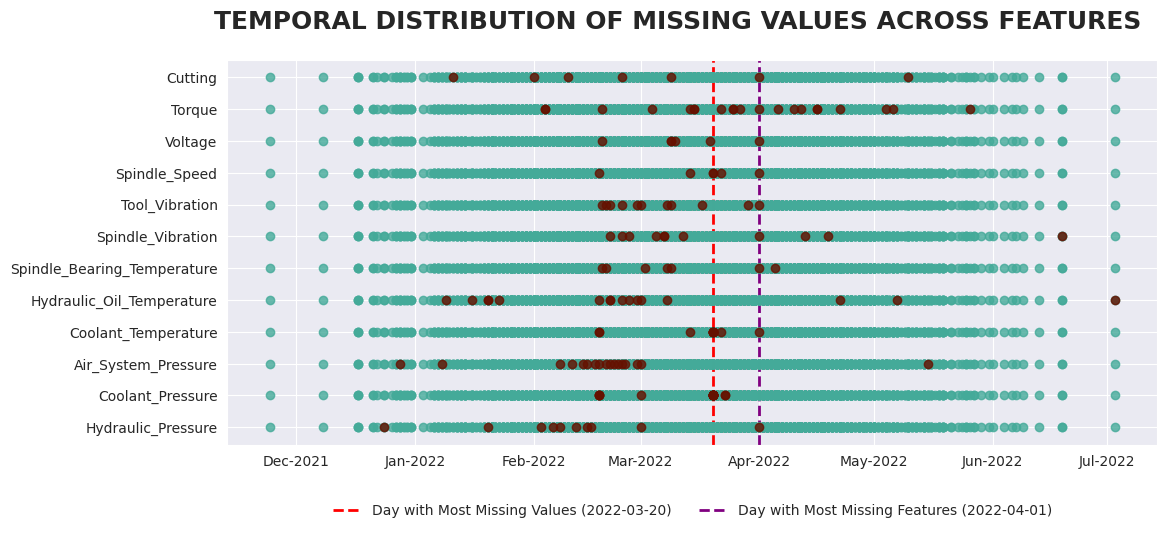

In [6]:
# Dates with the most missing values
missing_by_date = df.isna().sum(axis=1).groupby(df['Date']).sum().reset_index(name='missing_count_by_day')
missing_by_date = missing_by_date.sort_values(by='missing_count_by_day', ascending=False)
most_missing_date = pd.to_datetime(missing_by_date['Date'].iloc[0])

# Get the date of most missing features
most_missing_features_by_date = df.isna().groupby(df['Date']).apply(lambda x: len(set(x.columns[x.any()]))).sort_values(ascending=False).head(1)

fig, axes = plt.subplots(1, 1, figsize=(12, 5))
ax = axes

for feature in missing_df[missing_df > 0].index:
    data = df[df[feature].isna()].sort_values('Date')
    feature_data = df[[feature, 'Date']].sort_values('Date')
    
    # Plot readings timeline (without adding label to legend)
    ax.scatter(
        feature_data['Date'], 
        [feature] * len(feature_data), 
        color=palette[2], 
        alpha=0.8, 
        zorder=3
    )

    # Plot missing data timeline (without adding label to legend)
    ax.scatter(
        data['Date'], 
        [feature] * len(data), 
        color=palette[9], 
        alpha=0.8, 
        zorder=3
    )

# Add a vertical line for the most missing date
ax.axvline(
    x=most_missing_date, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f"Day with Most Missing Values ({most_missing_date.date()})"
)
# Add a vertical line for the most missing date
ax.axvline(
    x=most_missing_features_by_date.index[0], 
    color='purple', 
    linestyle='--', 
    linewidth=2, 
    label=f"Day with Most Missing Features ({most_missing_features_by_date.index[0].date()})"
)

# Add legend below the title
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

# Set labels, title, and rotation
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  
#ax.tick_params(axis='x', rotation=45)
#ax.tick_params(axis='y')

# Add title
fig.suptitle("Temporal Distribution of Missing Values Across Features".upper(), weight='bold', fontsize=18)

#plt.tight_layout()
plt.show()

- There are three machines, one for each assembly line.
- The machine ID `Makino-L2-Unit1-2015` (from the assembly line `Shopfloor-L2`) has the most missing values.

In [7]:
# Missing values by machine
for machine_id in sorted(df['Machine_ID'].unique()):
    assembly_line = df[df['Machine_ID'] == machine_id]['Assembly_Line_No'].head(1).values[0]
    print(f"Machine_ID '{machine_id}' (Assembly Line '{assembly_line}') has {df[df['Machine_ID'] ==machine_id].isna().sum().sum()} missing values.")
#df[['Assembly_Line_No','Machine_ID']].drop_duplicates()# Combination of Machine_ID per assembly line

Machine_ID 'Makino-L1-Unit1-2013' (Assembly Line 'Shopfloor-L1') has 49 missing values.
Machine_ID 'Makino-L2-Unit1-2015' (Assembly Line 'Shopfloor-L2') has 57 missing values.
Machine_ID 'Makino-L3-Unit1-2015' (Assembly Line 'Shopfloor-L3') has 37 missing values.


**Missing values by features**: Although all numeric features contain missing values, they account for less than 1% of observations. However, Torque, Coolant_Pressure, Air_System_Pressure, and Hydraulic_Oil_Temperature exhibit the highest missing rates, each exceeding 0.52%, which is above the 75th percentile of missingness distribution. This pattern suggests that these processes may involve more extreme conditions, potentially shortening sensor lifespan or making data collection more challenging. Further investigation would be needed to confirm these hypotheses.
  
**Missingness Correlation:** There is a notable connection between missing values in Coolant_Pressure, Coolant_Temperature, and Spindle_Speed. This relationship could stem from the measurement process itself or the equipment involved—such as shared sensors—where failures or specific operating conditions may lead to simultaneous data omissions. These correlations suggest that missing values may not be purely random but rather influenced by underlying mechanical or operational factors.
  
- Strong positive correlation (0.6): Coolant_Temperature ↔ Coolant_Pressure
- Strong positive correlation (0.6): Coolant_Temperature ↔ Spindle_Speed
- Weak positive correlation (0.3): Spindle_Speed ↔ Coolant_Pressure

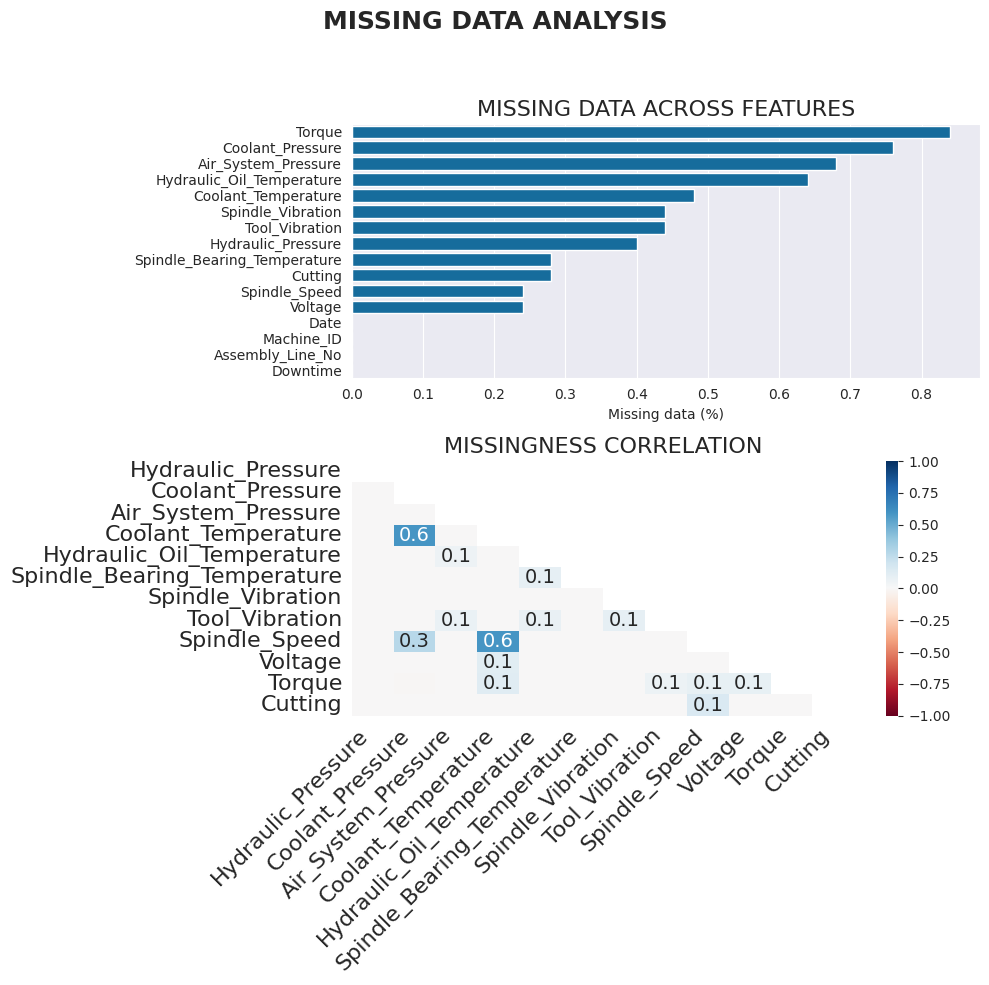

In [8]:
# Bar plot missing data by features
fig, axes = plt.subplots(2, 1, sharey=False,figsize=(10, 10))

# Subplot 1: Timeline evolution
ax = axes[0]
sns.barplot(
    data=missing_summary,
    y='feature',
    x='Normalized (%)',
    color=palette[-1],
    #hue='Assembly_Line_No',
    #palette=assembly_line_color_map,
    ax=ax
)
ax.set_title('Missing Data Across Features'.upper(),fontsize=16)
ax.set_ylabel('')
ax.set_xlabel('Missing data (%)')
#ax.tick_params(axis='x', rotation=45)

# Subplot 2:
ax = axes[1]
msno.heatmap(df, ax=ax)
ax.set_title('Missingness Correlation'.upper(),fontsize=16)

# Add an overall title
fig.suptitle('Missing Data Analysis\n\n'.upper(), weight='bold', fontsize=18)

# Adjust layout
plt.tight_layout()#(rect=[0, 0.05, 1, 0.95])  
plt.show()

**Missingness Clustering:** The dendrogram highlights a clustering of operational factors (Date, Machine_ID, Assembly_Line_No, and Downtime) at level zero, with Spindle_Speed connecting at a distance of about 2. This suggests that missing values in Spindle_Speed may be influenced by these factors, potentially indicating an operational dependency.

   Additionally, the sequential clustering of other features suggests relatively independent missingness patterns, aligning with the weak correlations observed in the heatmap. This reinforces the idea that while some missing values are linked to operational conditions, others may arise from distinct, unrelated causes.

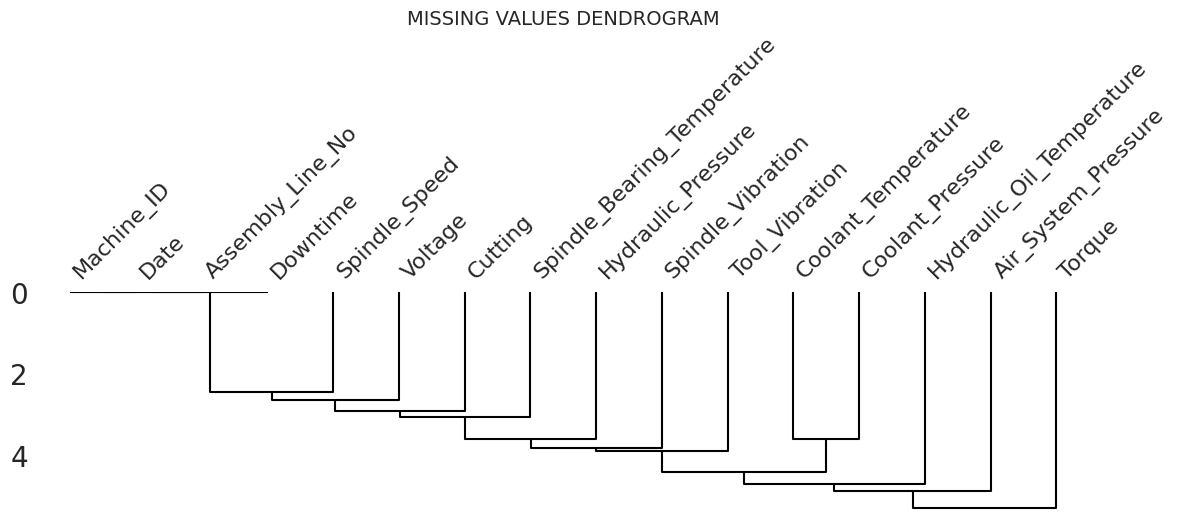

In [9]:
# Dendrogram of missigness
fig, axes = plt.subplots(1, 1, sharey=False, figsize=(12, 6))
ax = axes
msno.dendrogram(df, ax=ax)
ax.set_title('Missing Values Dendrogram'.upper(), fontsize=14)
#fig.suptitle('Missing Values on Dataset Features'.upper(), weight='bold', fontsize=16)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust rect to fit the title
plt.show()



The dataset exhibits good quality, with no duplicates and a low level of missingness—only 143 missing values, with each feature having less than 1% of its observations missing. Given these conditions, despite some correlations in missingness, the simplicity of median imputation (based on machine and operational status) will be sufficient.

However, further details about the data collection process, such as the methodologies and strategies used, are necessary to fully assess data quality. This is particularly important because occasional peaks in missing values (notably on days with the highest missing data and features) were observed. The correlations in missingness suggest a potential link between features due to shared sensors or measurement processes, and the possibility of operational factors (like sensor lifespan reduction) influencing the missing data. These hypotheses require further investigation to validate.

**The next steps in identifying patterns and causes of machine failures, which will enable proactive measures to minimize interruptions, include comparing data across different machines and operational statuses, as well as analyzing distributions and correlations. This will help uncover relationships between variables and identify factors contributing to machine downtime.**

### Temporal Distribution of Readings



**Dataset Span**

- The dataset covers 7 months (221 days) with almost daily readings.
 

**Timeline Overview** 
- Readings began in late November 2021 with Makino-L3-Unit1-2015, followed by Makino-L2-Unit1-2015 in early December, and Makino-L1-Unit1-2013 in mid-December.
- Data collection continued until July 2022 for Makino-L3 and Makino-L2, while Makino-L1 received readings until June 2022.

**Imbalance and Gaps**

- The number of readings was unevenly distributed across machines.
- Significant gaps were observed, particularly at the beginning and end of the dataset's time span.

In [10]:
# First and last readings
print(f"First reading: {df['Date'].min().date()} ")
print(f"Last reading: {df['Date'].max().date()} ")
#print(f"-> The first reading occurred on {df['Date'].min().strftime('%b %d, %Y')} and the last on {df['Date'].max().strftime('%b %d, %Y')}")

First reading: 2021-11-24 
Last reading: 2022-07-03 


In [11]:
# Distribution of readings across machines
df.groupby(['Machine_ID'])['Assembly_Line_No'].count().to_frame().rename(columns={'Assembly_Line_No': 'Total_readings'}).transpose()

Machine_ID,Makino-L1-Unit1-2013,Makino-L2-Unit1-2015,Makino-L3-Unit1-2015
Total_readings,874,808,818


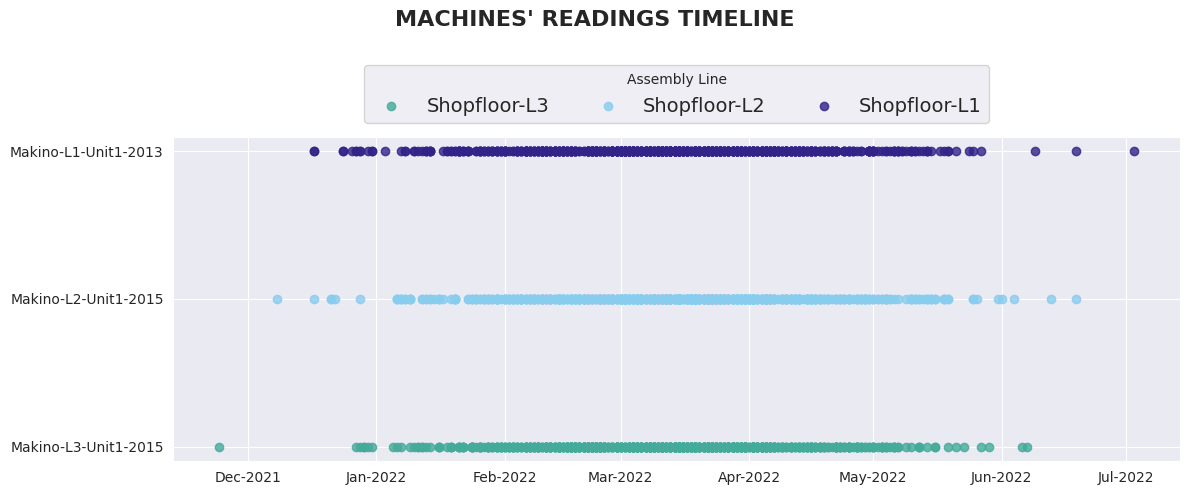

In [12]:
# Distribution of readings across time
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# Get all combinations of 'Machine_ID' and 'Assembly_Line_No' as tuples
combinations = list(zip(df[['Machine_ID', 'Assembly_Line_No']].drop_duplicates()['Machine_ID'],
                               df[['Machine_ID', 'Assembly_Line_No']].drop_duplicates()['Assembly_Line_No']))

# Subplot 1: Operational data timeline
ax = axes
plotted_labels = set()  # To avoid duplicate labels in the legend

for combination in combinations:
    machineid = combination[0]
    assembly_line_no = combination[1]
    data = df[(df['Machine_ID'] == machineid) & (df['Assembly_Line_No'] == assembly_line_no)].sort_values('Date')
    
    # Find the color for the current Assembly_Line_No
    color = assembly_line_color_map[assembly_line_no]
    
    # Plot the scatter plot with transparency
    ax.scatter(
        data['Date'], 
        [machineid] * len(data), 
        color=color, 
        alpha=0.8, 
        label=assembly_line_no if assembly_line_no not in plotted_labels else None, 
        zorder=3
    )
    plotted_labels.add(assembly_line_no)

# Set labels, title, and rotation
ax.set_xlabel('')
ax.set_ylabel('')

# Format x-axis to show month-year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Adjust interval as needed
#ax.tick_params(axis='y', rotation=45)
#ax.tick_params(axis='x', rotation=45)
#ax.set_title("")

# Add legend without duplicates
ax.legend(
    title=columns_print_names['Assembly_Line_No'], 
    bbox_to_anchor=(0.5, 1.25), 
    loc='upper center', 
    ncol=3, 
    frameon=True,
    fontsize=14
)

fig.suptitle("Machines' Readings Timeline".upper(), weight='bold', fontsize=16)
#fig.text(0.5, 0.86, "\n", fontsize=13, ha='center')

plt.tight_layout()
plt.show()

**Longest Continuous Period**
- Makino-L3-Unit1-2015 had gaps of up to 33 days at the start, whereas Makino-L2-Unit1-2015 and Makino-L1-Unit1-2013 had gaps of up to 9 and 14 days, respectively.
  
- Consistent daily readings across all three machines started in late January 2022 and lasted until around May, averaging about 100 consecutive days of readings across all machines.

In [13]:
# Calculate the difference between readings dates by Machine_ID
print("GAPS BETWEEN READINGS (IN DAYS) BY MACHINE:".upper())

date_diffs_by_machine = (
    df.groupby('Machine_ID')['Date']
    .apply(lambda x: x.sort_values().diff().dt.days)
)
date_diffs_by_machine.groupby('Machine_ID').describe()

GAPS BETWEEN READINGS (IN DAYS) BY MACHINE:


,count,mean,std,min,25%,50%,75%,max
Machine_ID,,,,,,,,
Makino-L1-Unit1-2013,873.0,0.226804,0.877270,0.0,0.0,0.0,0.0,14.0
Makino-L2-Unit1-2015,807.0,0.239157,0.794555,0.0,0.0,0.0,0.0,9.0
Makino-L3-Unit1-2015,817.0,0.238678,1.273051,0.0,0.0,0.0,0.0,33.0


In [14]:
# Find the longest consecutive period per machine
print("Longest consecutive reading period per machine:\n".upper())

longest_periods = []

for machine, machine_dates in df.groupby('Machine_ID')['Date']:
    sorted_dates = machine_dates.sort_values().drop_duplicates()
    date_diffs = sorted_dates.diff().dt.days

    # Identify gaps greater than 1 day
    gap_mask = date_diffs > 1
    period_groups = gap_mask.cumsum()

    # Group by consecutive periods
    consecutive_periods = sorted_dates.groupby(period_groups)

    # Find the longest period (fix: extract only the Series from the tuple)
    longest_period = max(
        consecutive_periods, 
        key=lambda g: (g[1].max() - g[1].min()).days,  # Extracting the Series g[1]
        default=None
    )

    if longest_period is not None:
        start_date = longest_period[1].min()
        end_date = longest_period[1].max()
        days_num = (end_date - start_date).days + 1
        longest_periods.append((machine, start_date, end_date, days_num))

        print(f"{machine}")
        print(f"  Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')} (about {days_num} days)\n")


LONGEST CONSECUTIVE READING PERIOD PER MACHINE:

Makino-L1-Unit1-2013
  Period: 2022-01-25 to 2022-04-22 (about 88 days)

Makino-L2-Unit1-2015
  Period: 2022-01-23 to 2022-05-07 (about 105 days)

Makino-L3-Unit1-2015
  Period: 2022-01-24 to 2022-05-07 (about 104 days)



**Number of Daily Readings**
  
- From January to mid-March, the number of daily readings increased significantly, peaking at a 7-day rolling average of over 12 readings per day. Afterward, the readings began to decline, stabilizing at around three daily readings from May onward.
  
- Overall, the average number of daily readings was around five. While the 7-day rolling averages across all machines were very similar, Shopfloor-L2 stood out due to occasional spikes, with daily readings reaching up to 27 readings in a single day.
  

In [15]:
# Daily Readings distribution by Assembly_Line_No 
readings_count = df.groupby(['Date', 'Assembly_Line_No'])['Machine_ID'].count().reset_index(name='readings_per_day')

print("Daily Readings by Assembly Line:".upper())
readings_count.groupby('Assembly_Line_No')['readings_per_day'].describe()

DAILY READINGS BY ASSEMBLY LINE:


,count,mean,std,min,25%,50%,75%,max
Assembly_Line_No,,,,,,,,
Shopfloor-L1,164.0,5.329268,4.872749,0.0,1.0,4.0,9.0,22.0
Shopfloor-L2,164.0,4.926829,4.468789,0.0,1.0,4.0,7.0,27.0
Shopfloor-L3,164.0,4.987805,4.721687,0.0,1.0,4.0,8.0,20.0


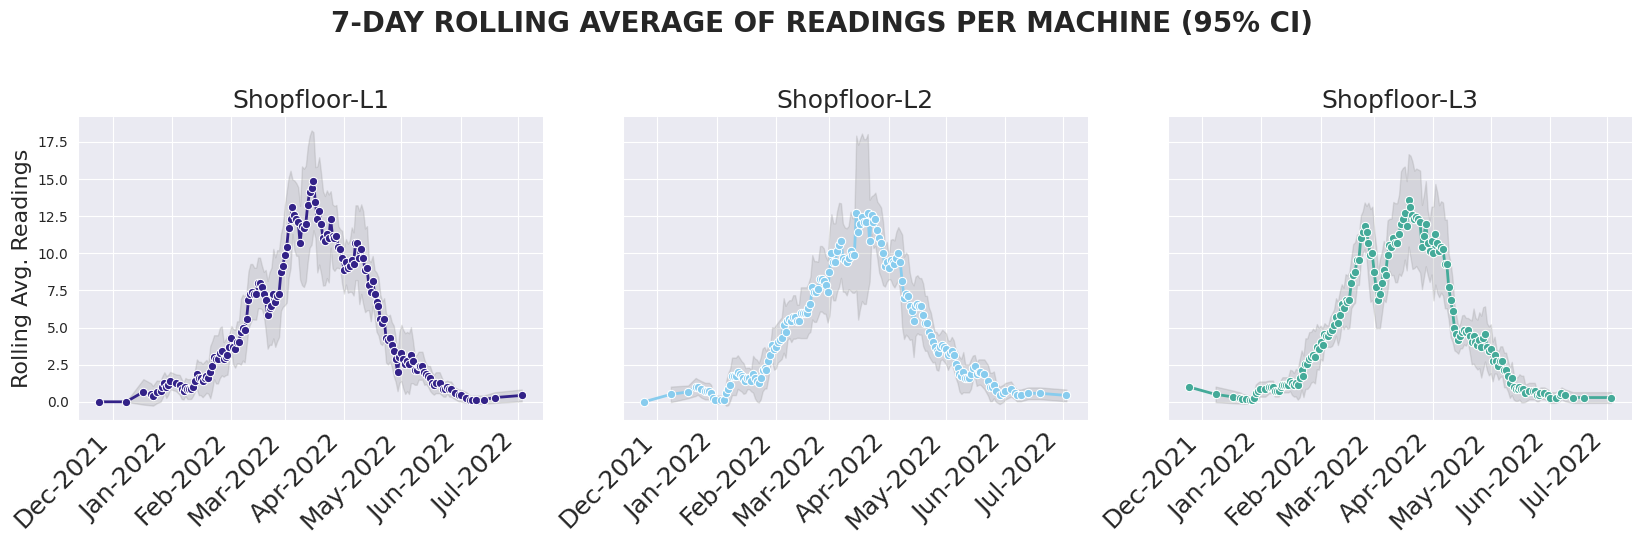

In [16]:
#7-Day Rolling Average of Readings Per Machine (95% CI)

# Calculate rolling mean and standard deviation for a smoother trend
readings_count['rolling_avg'] = readings_count.groupby('Assembly_Line_No')['readings_per_day'].transform(lambda x: x.rolling(7, min_periods=1).mean())  # 7-day moving average
readings_count['rolling_std'] = readings_count.groupby('Assembly_Line_No')['readings_per_day'].transform(lambda x: x.rolling(7, min_periods=1).std())

# Calculate confidence intervals (mean ± 1.96 * std / sqrt(n))
readings_count['ci_lower'] = readings_count['rolling_avg'] - (1.96 * readings_count['rolling_std'] / np.sqrt(7))
readings_count['ci_upper'] = readings_count['rolling_avg'] + (1.96 * readings_count['rolling_std'] / np.sqrt(7))

# FacetGrid for each machine
g = sns.FacetGrid(data=readings_count, col='Assembly_Line_No', col_wrap=3, height=5.5, aspect=1.0, sharey=True)

# Plot the rolling mean and confidence interval as a shaded region
def plot_ci(x, y, **kwargs):
    ax = plt.gca()
    machine = kwargs['data']['Assembly_Line_No'].iloc[0]
    sub_df = kwargs['data']
    ax.fill_between(sub_df[x], sub_df['ci_lower'], sub_df['ci_upper'], alpha=0.2, color='gray')
    sns.lineplot(data=sub_df, x=x, y=y, ax=ax, linestyle='solid', color=assembly_line_color_map[machine], marker='o', lw=2)

g.map_dataframe(plot_ci, 'Date', 'rolling_avg')

# Adjust x-axis
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Titles and labels
g.set_axis_labels('', 'Rolling Avg. Readings', fontsize=16)
g.set_titles(col_template="{col_name}", size=18)
g.set_xticklabels(rotation=45, horizontalalignment='right', fontsize=18)
g.fig.suptitle("7-Day Rolling Average of Readings Per Machine (95% CI)\n".upper(), weight='bold', fontsize=20)

plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

In [17]:
# Comparing the overall mean, variance, skewness, and kurtosis of daily readings across machines to identifying general differences in their distributions. 
from scipy.stats import kurtosis
from scipy.stats import skew

column_name = 'readings_per_day'#'rolling_avg'
print("Skewness of daily readings across machines: ".upper())
print(readings_count.groupby('Assembly_Line_No')[column_name].apply(skew))

print("\nKurtosis of the daily readings across machines: ".upper())
print(readings_count.groupby('Assembly_Line_No')[column_name].apply(kurtosis))

print("\nOverall stats of the daily readings across machines: ".upper())
print(readings_count.groupby('Assembly_Line_No')[column_name].describe().round(2))


SKEWNESS OF DAILY READINGS ACROSS MACHINES: 
Assembly_Line_No
Shopfloor-L1    0.865438
Shopfloor-L2    1.225938
Shopfloor-L3    0.928379
Name: readings_per_day, dtype: float64

KURTOSIS OF THE DAILY READINGS ACROSS MACHINES: 
Assembly_Line_No
Shopfloor-L1   -0.028386
Shopfloor-L2    2.481788
Shopfloor-L3    0.156382
Name: readings_per_day, dtype: float64

OVERALL STATS OF THE DAILY READINGS ACROSS MACHINES: 
                  count  mean   std  min  25%  50%  75%   max
Assembly_Line_No                                             
Shopfloor-L1      164.0  5.33  4.87  0.0  1.0  4.0  9.0  22.0
Shopfloor-L2      164.0  4.93  4.47  0.0  1.0  4.0  7.0  27.0
Shopfloor-L3      164.0  4.99  4.72  0.0  1.0  4.0  8.0  20.0


**Data Quality Remarks from the Temporal Distribution Analysis**

The dataset spans approximately seven months with mostly daily readings, though there are noticeable gaps, especially at the start and end. This suggests potential issues like incomplete data collection, sensor activation/deactivation, or reporting inconsistencies that require further clarification.

The number of daily readings fluctuated, peaking at over 12 readings per day in the 7-day rolling average, then declining to about 3 per day. This variability could be due to irregular data logging, changes in monitoring frequency, or machine-specific factors.

Next Steps for Data Quality:

- Investigate gaps in daily readings, especially at the beginning and end of the dataset.
- Check if gaps coincide with maintenance schedules or operational changes.
- Analyze the causes of fluctuating data collection frequency and explore standardizing monitoring practices to reduce variability.

### Downtime Rate Analysis

The downtime rate analysis is affected by data gaps and uneven reading frequencies. Higher reading frequency likely provides a more accurate downtime representation, and it may lead to artificially stabilized downtime averages.

To Improve Analysis:

- Further investigation into data gaps and frequency variations is needed to validate trends.
- Standardizing data collection procedures and addressing data quality issues will lead to more reliable downtime rate insights.

The number of downtime occurrences increased and peaked between March and April, then decreased again. While typical daily downtime averaged around 2–3 events per assembly line, occasional spikes of up to 12 events indicate periods of intensified operational disruption.

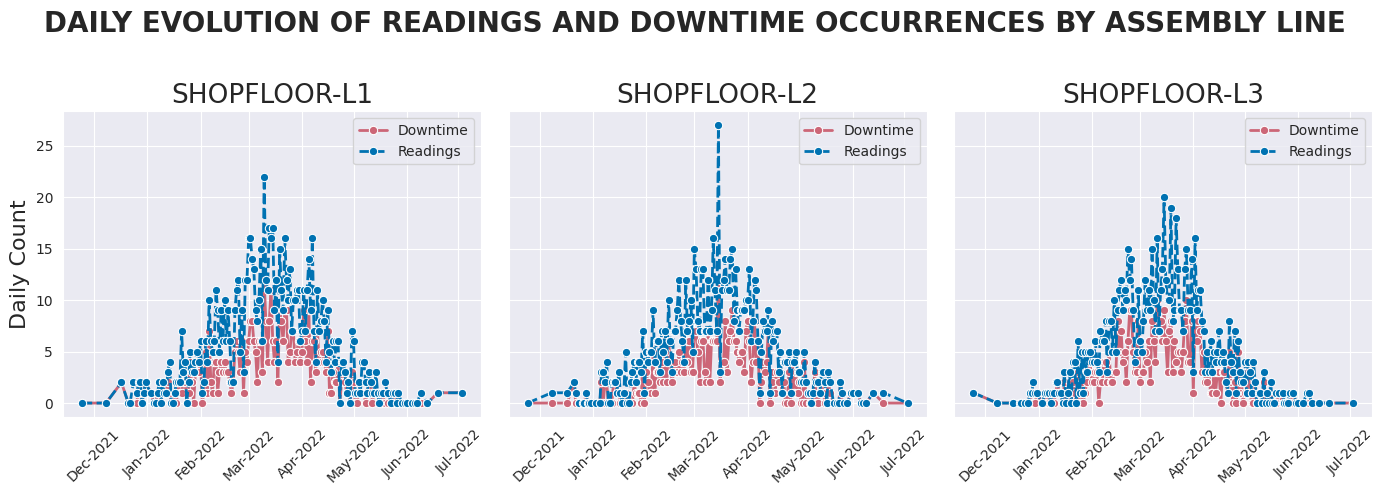

In [18]:
# Aggregate downtime by day
df['Day'] = df['Date'].dt.to_period('D')
df['Day'] = df['Day'].dt.start_time

# Count the number of measuments per assembly_line by week
daily_assembly_line_count = df.groupby(['Day', 'Assembly_Line_No']).size().reset_index(name='entry_count')

# Count the number of downtimes per assembly_line by week
downtime_by_assembly_line_daily = df.groupby(['Day', 'Assembly_Line_No'])['Downtime'].sum().reset_index(name='Downtime_occurrences')

# Plotting the evolution of downtime by assembly_line in a 3-column layout
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(14, 5))

# Define the assembly_lines you want to plot (for example, the first 3 unique assembly_lines)
assembly_lines = downtime_by_assembly_line_daily['Assembly_Line_No'].unique()[:3]

# Plot the downtime evolution for each assembly_line
for i, assembly_line in enumerate(assembly_lines):
    ax = axes[i]
    data = downtime_by_assembly_line_daily[downtime_by_assembly_line_daily['Assembly_Line_No'] == assembly_line]
    
    # Plotting the downtime evolution with color red and confidence interval of 95%
    sns.lineplot(data=data, x='Day', y='Downtime_occurrences', ax=ax, color=palette[6], ci=95, marker='o', lw=2, label="Downtime")
    sns.lineplot(data=daily_assembly_line_count[daily_assembly_line_count['Assembly_Line_No'] == assembly_line], x='Day', y='entry_count', color=palette[-1], ax=ax, linestyle='--',marker='o',  lw=2, label="Readings")
    
    ax.set_title(f'{assembly_line}'.upper(), fontsize=19)
    ax.set_xlabel('')
    ax.set_ylabel('Daily Count', fontsize=16)
    ax.tick_params(axis='x', rotation=45)

    # Format x-axis to show month-year labels
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  

# Add a main title for the entire figure
fig.suptitle(f"Daily Evolution of Readings and Downtime occurrences by {columns_print_names['Assembly_Line_No']}".upper(), weight='bold', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [19]:
# Daily downtime occurences
downtime_by_assembly_line_daily.groupby("Assembly_Line_No")['Downtime_occurrences'].describe()

,count,mean,std,min,25%,50%,75%,max
Assembly_Line_No,,,,,,,,
Shopfloor-L1,164.0,2.768293,2.710121,0.0,1.0,2.0,4.0,12.0
Shopfloor-L2,164.0,2.414634,2.436689,0.0,0.0,2.0,4.0,12.0
Shopfloor-L3,164.0,2.530488,2.650208,0.0,0.0,2.0,4.0,10.0


The peaks in both the number of readings and downtime occurrences appear proportional, suggesting a deliberate effort to anticipate potential downtime events. Furthermore, the increase in both metrics is observed during the largest continuous period of daily readings, spanning from January to May 2022. 

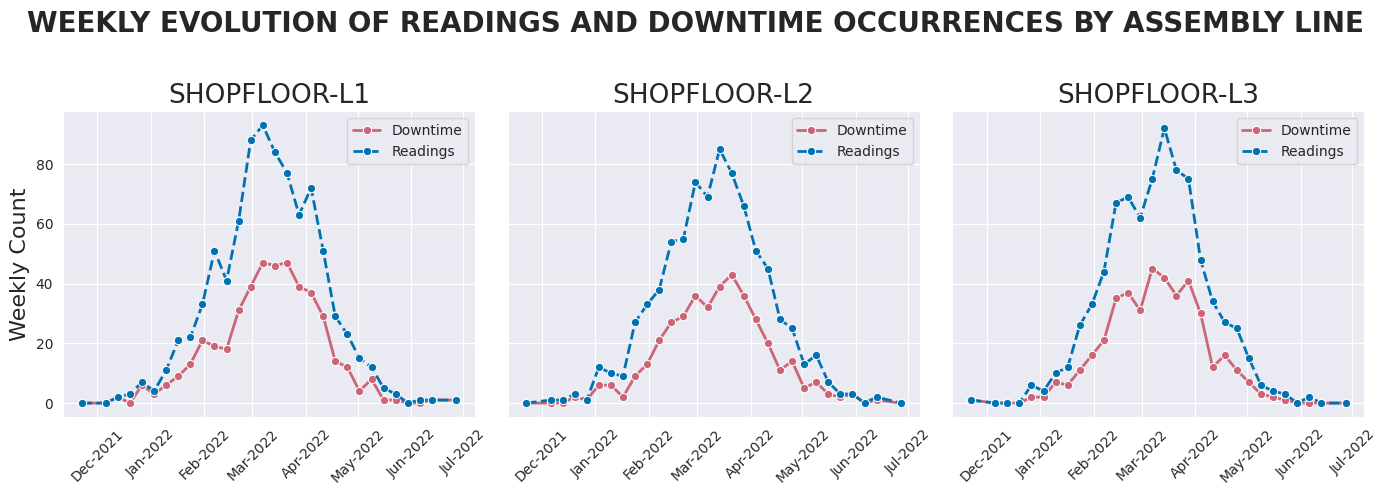

In [20]:
# Aggregate downtime by week
df['Week'] = df['Date'].dt.to_period('W')
df['Week'] = df['Week'].dt.start_time

# Count the number of measuments per assembly_line by week
weekly_assembly_line_count = df.groupby(['Week', 'Assembly_Line_No']).size().reset_index(name='entry_count')

# Count the number of downtimes per assembly_line by week
downtime_by_assembly_line_weekly = df.groupby(['Week', 'Assembly_Line_No'])['Downtime'].sum().reset_index(name='Downtime_occurrences')

# Plotting the evolution of downtime by assembly_line in a 3-column layout
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(14, 5))

# Define the assembly_lines you want to plot (for example, the first 3 unique assembly_lines)
assembly_lines = downtime_by_assembly_line_weekly['Assembly_Line_No'].unique()[:3]

# Plot the downtime evolution for each assembly_line
for i, assembly_line in enumerate(assembly_lines):
    ax = axes[i]
    data = downtime_by_assembly_line_weekly[downtime_by_assembly_line_weekly['Assembly_Line_No'] == assembly_line]
    
    # Plotting the downtime evolution with color red and confidence interval of 95%
    sns.lineplot(data=data, x='Week', y='Downtime_occurrences', ax=ax, color=palette[6], ci=95, marker='o', lw=2, label="Downtime")
    sns.lineplot(data=weekly_assembly_line_count[weekly_assembly_line_count['Assembly_Line_No'] == assembly_line], x='Week', y='entry_count', color=palette[-1], ax=ax, linestyle='--',marker='o',  lw=2, label="Readings")
    
    ax.set_title(f'{assembly_line}'.upper(), fontsize=19)
    ax.set_xlabel('')
    ax.set_ylabel('Weekly Count', fontsize=16)
    ax.tick_params(axis='x', rotation=45)

    # Format x-axis to show month-year labels
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  

# Add a main title for the entire figure
fig.suptitle(f"Weekly Evolution of Readings and Downtime occurrences by {columns_print_names['Assembly_Line_No']}".upper(), weight='bold', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

At least one downtime occurrence was recorded almost every week, with only two weeks without any downtime occurrences (the 2nd week of December 2021 and the 28th week of June 2022).


In [21]:
# Create columns for week number, day of the week, and month-year
df['Week_Of_Year'] = df['Date'].dt.isocalendar().week
df['Day_Of_Week'] = df['Date'].dt.dayofweek
df['Month_Year'] = df['Date'].dt.strftime('%b-%Y')  # Format as "Jan-2022", "Feb-2022", etc.
df['Month'] = df['Date'].dt.strftime('%m')  
df['Year'] = df['Date'].dt.strftime('%Y')  

# Map the weeks to ordinal_week
unique_weeks = df[['Date', 'Week_Of_Year']].drop_duplicates().sort_values('Date')
week_mapping = {week: idx + 1 for idx, week in enumerate(unique_weeks['Week_Of_Year'].unique())}
df['Ordinal_Week'] = df['Week_Of_Year'].map(week_mapping)

dayofweek_labels = dict(zip(list(range(0,7)), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']))

#Monday=0, Sunday=6
counts_df = df[df['Downtime'] == 1].drop_duplicates(subset='Date', keep='first')
counts_df['Day_Of_Week'] = counts_df['Day_Of_Week'].replace(dayofweek_labels)

weeks_downtime = counts_df.groupby('Week_Of_Year')['Downtime'].count().reset_index(name='Days with Any Downtime Occurrences')
total_weeks_downtime = len(weeks_downtime[weeks_downtime['Days with Any Downtime Occurrences'] > 0])
dataset_num_weeks = df['Week_Of_Year'].nunique()
percent_weeks_downtime = round((total_weeks_downtime/dataset_num_weeks)*100, 2)
weeks_without_downtime = int(dataset_num_weeks - round((percent_weeks_downtime * dataset_num_weeks)/100, 0))
print(f"\nTotal of {percent_weeks_downtime}% of the weeks with occurrences of downtime (only {weeks_without_downtime} weeks without any downtime).\n")

# Weeks with no downtime
weeks_with_downtime = set(weeks_downtime['Week_Of_Year'].values)
weeks_df = set(df['Week_Of_Year'].values)
no_downtime_weeks = list(weeks_df.difference(weeks_with_downtime))

print("ORDINAL WEEKS WITH NO DOWNTIME OCCURRENCES:")
df[df['Week_Of_Year'].isin(no_downtime_weeks)][['Date', 'Ordinal_Week']].drop_duplicates(subset=['Date'], keep='first').sort_values(by='Date')


Total of 93.33% of the weeks with occurrences of downtime (only 2 weeks without any downtime).

ORDINAL WEEKS WITH NO DOWNTIME OCCURRENCES:


,Date,Ordinal_Week
1823,2021-12-08,2
1981,2022-06-06,28
1895,2022-06-07,28
1755,2022-06-09,28


There were 48 days with a 100% downtime rate, where all sensor readings indicated downtime. However, these days had a lower-than-average number of daily readings, suggesting potential bias in the data. Additionally, the downtime was limited to just one or, at most, two assembly lines at a time, as illustrated below.

The machine Makino-L1-Unit1-2013 (assembly line `Shopfloor-L1`) had the most number of 100% downtime occurrences (22), followed by Makino-L3-Unit1-2015 (19) and Makino-L2-Unit1-2015 (17).

In [22]:
# Assembly lines with 100% downtime stats

# Calculate the downtime rate per date
downtime_per_date = df.groupby(['Machine_ID', 'Date'])['Downtime'].mean().mul(100).round(2).reset_index()
downtime_per_date['day'] = downtime_per_date['Date'].dt.day_name()

#full_downtime = downtime_rate_by_assembly_line_daily[downtime_rate_by_assembly_line_daily['Downtime_rate'] ==100].sort_values('Date')
full_downtime = downtime_per_date[downtime_per_date['Downtime'] == 100].sort_values('Date')

print(f"Number of days with one or more machines with 100% downtime rate: {full_downtime['Date'].nunique()} days.")
print(f"Number of assembly lines with 100% downtime rate at the same day: {full_downtime.groupby('Date')['Machine_ID'].count().max()} machines/assembly lines.")

# Number of 100% Downtime Occurrences
full_downtime.groupby(['Machine_ID'])['Downtime'].count().rename('Number of 100% Downtime Occurrences')

Number of days with one or more machines with 100% downtime rate: 48 days.
Number of assembly lines with 100% downtime rate at the same day: 2 machines/assembly lines.


Machine_ID
Makino-L1-Unit1-2013    22
Makino-L2-Unit1-2015    17
Makino-L3-Unit1-2015    19
Name: Number of 100% Downtime Occurrences, dtype: int64

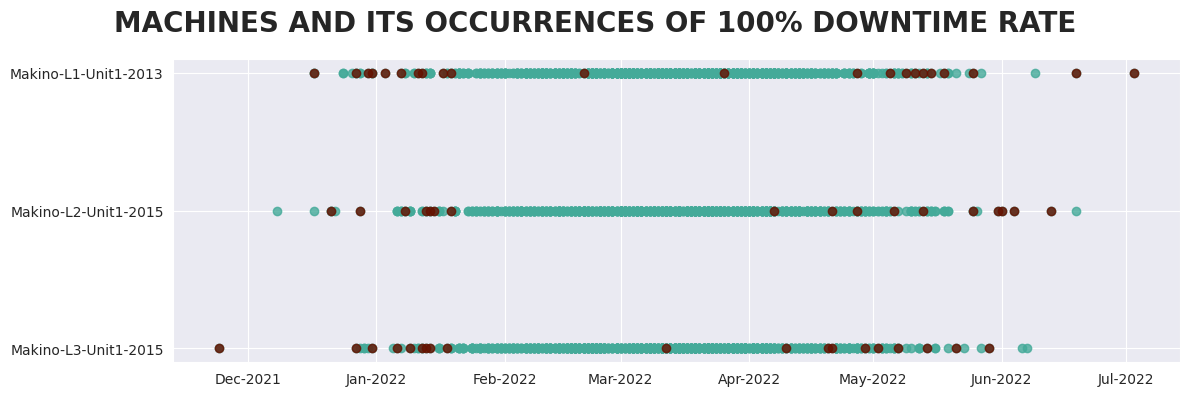

In [23]:
# Distribution of readings across time
fig, axes = plt.subplots(1, 1, figsize=(12,4))

# Subplot 1: Operational data timeline
ax = axes
plotted_labels = set() 

for combination in df['Machine_ID'].unique():
    machineID = combination
    data = df[(df['Machine_ID'] == machineID)].sort_values('Date')
    
    # Find the color for the current Assembly_Line_No
    #color = assembly_line_color_map[assembly_line_no]
    
    # Plot the scatter plot with transparency
    ax.scatter(
        data['Date'], 
        [machineID] * len(data), 
        color=palette[2], 
        alpha=0.8, 
        label=machineID if machineID not in plotted_labels else None, 
        zorder=3
    )
    plotted_labels.add(machineID)

    # Plot missing data timeline (without adding label to legend)
    machine_full_downtime = full_downtime[full_downtime['Machine_ID']==machineID]
    ax.scatter(
        machine_full_downtime['Date'], 
        [machineID] * len(machine_full_downtime), 
        color=palette[9], 
        alpha=0.8, 
        zorder=3
    )

# Set labels, title, and rotation
ax.set_xlabel('')
ax.set_ylabel('')

# Format x-axis to show month-year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Adjust interval as needed
#ax.tick_params(axis='y', rotation=45)
#ax.tick_params(axis='x', rotation=45)
#ax.set_title("")

# Add legend without duplicates
#ax.legend(
#    title=columns_print_names['Assembly_Line_No'], 
#    bbox_to_anchor=(0.5, 1.2), 
#    loc='upper center', 
#    ncol=3, 
#    frameon=True  # This removes the legend's frame
#)

fig.suptitle("Machines and its Occurrences of 100% Downtime Rate".upper(), weight='bold', fontsize=20)
#fig.text(0.5, 0.86, "\n", fontsize=13, ha='center')

plt.tight_layout()
plt.show()

**Weekly Patterns:** While downtime occurred on every day of the week, Saturdays had a 100% occurrence rate, whereas Wednesdays had the lowest frequency (around 84%).

In [24]:
# Count of total number of days in the whole period
count_days = df.drop_duplicates(subset='Date', keep='first')['Day_Of_Week'].replace(dayofweek_labels).value_counts().reset_index(name='Total days')

downtime_counts = counts_df.groupby('Day_Of_Week')['Downtime'].count().reset_index(name='Days with Any Downtime Occurrences')
downtime_counts = downtime_counts.merge(count_days, on='Day_Of_Week')
downtime_counts['% Downtime Days'] =  round((downtime_counts['Days with Any Downtime Occurrences'] / downtime_counts['Total days'] )*100, 2)
downtime_counts.sort_values(by='% Downtime Days', ascending=False)

,Day_Of_Week,Days with Any Downtime Occurrences,Total days,% Downtime Days
2,Saturday,21,21,100.00
1,Monday,22,24,91.67
0,Friday,21,23,91.30
3,Sunday,21,23,91.30
4,Thursday,21,23,91.30
5,Tuesday,21,24,87.50
6,Wednesday,22,26,84.62


**Variation by Machine:** The distribution of downtime rates by days of the week varies significantly between machines.

**Range of Downtime:** Downtime rates ranged from 0% to 100% every day for all machines, except for Makino-L2-Unit1-2015 on Sundays, which reached a maximum of 66.67%.

**Consistent Median:** The median downtime rate is generally around 50%, indicating that failures commonly occur across all three machines.

**Quartile Distribution:**

- Makino-L1-Unit1-2013 has the highest downtime rates, with a median above 50% on five days of the week. The machine has the first quartiles starting at 25% for all days of the week. It On Wednesdays, the first quartile starts at 50%, while the third quartile reaches 100%, indicating the worst downtime levels.
- Makino-L2-Unit1-2015 and Makino-L3-Unit1-2015 show downtime rates mostly below 75% (third quartile), with higher quantiles on Wednesdays and Saturdays.
      
      

**Relative Stability:**

- Makino-L1-Unit1-2013 shows slight stability on Tuesdays and Thursdays, with the lowest medians and interquartile ranges (IQRs).
- Makino-L2-Unit1-2015 has the lowest downtime rates on Sundays, with both median and third quartile below 50%, and on Mondays, with the lowest median and a first quartile at 0% and the third slighlty above 50%.
- Makino-L3-Unit1-2015 has the lowest downtime rates on Mondays and Tuesdays, with medians below 50% and the lowest first quartile.

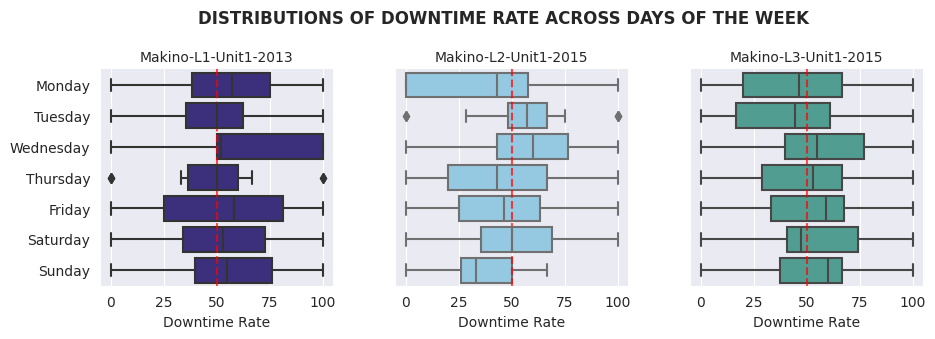

In [25]:
# Downtime rate per week day
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create the FacetGrid
g = sns.FacetGrid(downtime_per_date, col="Machine_ID", col_wrap=3, sharex=True, sharey=True)

# Loop through each subplot and assign the correct color
for machine_id, ax in zip(g.col_names, g.axes.flat):
    sns.boxplot(
        data=downtime_per_date[downtime_per_date["Machine_ID"] == machine_id],
        x="Downtime",
        y="day",
        order=weekday_order,
        ax=ax,
        color=machine_color_map[machine_id]  # Use the color from the dictionary
    )
    ax.axvline(50, linestyle="--", color='red', alpha=0.7)  # Match guide line color

# Adjust labels and titles
g.set_axis_labels("Downtime Rate", "")
g.set_titles("{col_name}")
g.set(yticks=range(len(weekday_order)), yticklabels=weekday_order)
g.fig.suptitle("Distributions of Downtime Rate Across days of the week\n".upper(), weight='bold', fontsize=12,   y=1.05)

# Adjust spacing to prevent overlap
plt.subplots_adjust(top=0.85)  # Shrinks plots a bit to fit the title
plt.show()

**Analysis of Downtime Rate with 7-Day Rolling Average**

**General Trend:** All three machines (Makino-L1-Unit1-2013, Makino-L2-Unit1-2015, and Makino-L3-Unit1-2015) showed downtime averages around 50% from February to June, indicating stable but significant downtime. This pattern, however, may be influenced by an increase in daily readings and higher reading frequency from January to mid-March, which could have contributed to the observed stability. Further analysis is needed to confirm if these factors are driving the 50% downtime average.

**Wider Confidence Intervals:** Wider confidence intervals at the beginning and end of the period suggest that gaps in the data and decreasing reading frequency led to greater variability in downtime rates.

**Machine-Specific Insights:**

- Makino-L1-Unit1-2013 & Makino-L3-Unit1-2015: Both started with higher downtime rates but showed significant improvement over time, with averages dropping below 50%.

- Makino-L2-Unit1-2015: Started with downtime below 50% but ended with consistently higher downtime rates above 50%, indicating a worsening trend.


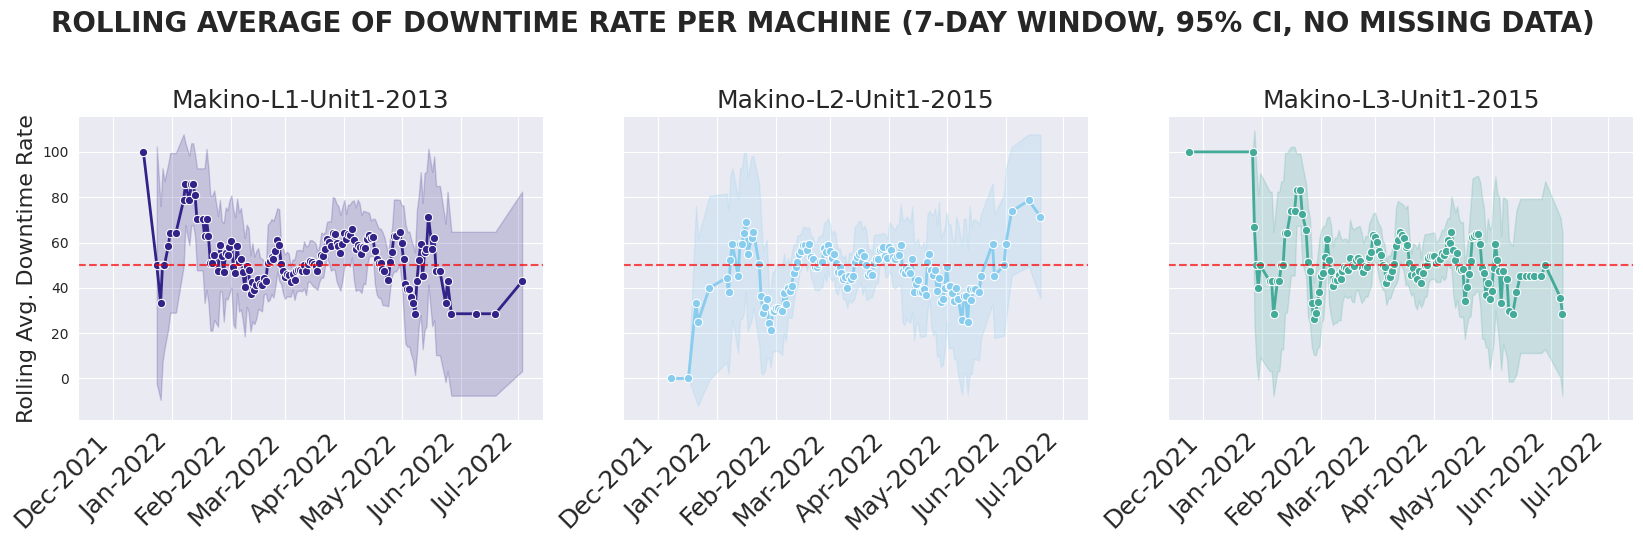

In [26]:
# Downtime rate per week: 7-day rolling mean per machine
downtime_per_date = df.groupby(['Machine_ID', 'Date'])['Downtime'].mean().mul(100).round(2).reset_index().dropna(subset='Downtime')

# Calculate rolling mean and standard deviation for a smoother trend
downtime_per_date['rolling_avg'] = downtime_per_date.groupby('Machine_ID')['Downtime'].transform(lambda x: x.rolling(7, min_periods=1).mean())
downtime_per_date['rolling_std'] = downtime_per_date.groupby('Machine_ID')['Downtime'].transform(lambda x: x.rolling(7, min_periods=1).std())

# Calculate confidence intervals (mean ± 1.96 * std / sqrt(n))
downtime_per_date['ci_lower'] = downtime_per_date['rolling_avg'] - (1.96 * downtime_per_date['rolling_std'] / np.sqrt(7))
downtime_per_date['ci_upper'] = downtime_per_date['rolling_avg'] + (1.96 * downtime_per_date['rolling_std'] / np.sqrt(7))

# FacetGrid for each machine
g = sns.FacetGrid(data=downtime_per_date, col='Machine_ID', col_wrap=3, height=5.5, aspect=1.0, sharey=True)

# Plot the rolling mean, confidence interval, and guide line
def plot_ci(x, y, **kwargs):
    ax = plt.gca()
    sub_df = kwargs['data']
    machine_id = sub_df['Machine_ID'].iloc[0]  # Get the machine ID
    color = machine_color_map.get(machine_id, 'gray')  # Default to gray if not in dict

    # Confidence interval shading
    ax.fill_between(sub_df[x], sub_df['ci_lower'], sub_df['ci_upper'], alpha=0.2, color=color)
    
    # Rolling mean line
    sns.lineplot(data=sub_df, x=x, y=y, ax=ax, linestyle='solid', marker='o', lw=2, color=color)

    # Guide line at 50%
    ax.axhline(y=50, linestyle="--", color="red", alpha=0.7)  # Dotted red line at 50%

g.map_dataframe(plot_ci, 'Date', 'rolling_avg')

# Adjust x-axis format
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Titles and labels
g.set_axis_labels('', 'Rolling Avg. Downtime Rate', fontsize=16)
g.set_titles(col_template="{col_name}", size=18)
g.set_xticklabels(rotation=45, horizontalalignment='right', fontsize=18)
g.fig.suptitle("Rolling Average of Downtime Rate Per Machine (7-Day Window, 95% CI, No Missing Data)\n".upper(), weight='bold', fontsize=20)


plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

**The 7-day rolling averages downtime rates are:** Makino-L1-Unit1-2013 had the highest downtime (54%), followed by Makino-L3-Unit1-2015 (51%) and Makino-L2-Unit1-2015 (46%).  

In [27]:
# Distribution of overall Downtime rates per date by machine
print("Distribution of overall Downtime rates per date by machine: ".upper())
downtime_per_date.groupby('Machine_ID')['Downtime'].describe()

DISTRIBUTION OF OVERALL DOWNTIME RATES PER DATE BY MACHINE: 


,count,mean,std,min,25%,50%,75%,max
Machine_ID,,,,,,,,
Makino-L1-Unit1-2013,141.0,53.668014,29.322515,0.0,36.36,50.0,71.43,100.0
Makino-L2-Unit1-2015,139.0,47.360288,30.530772,0.0,27.92,50.0,66.67,100.0
Makino-L3-Unit1-2015,136.0,49.797941,30.894651,0.0,30.00,50.0,66.67,100.0


In [28]:
# Distribution of 7-day rolling averages of Downtime rates by machine
#print("Distribution of 7-day rolling averages of Downtime rates by machine: ".upper())
#downtime_per_date.groupby('Machine_ID')['rolling_avg'].describe()

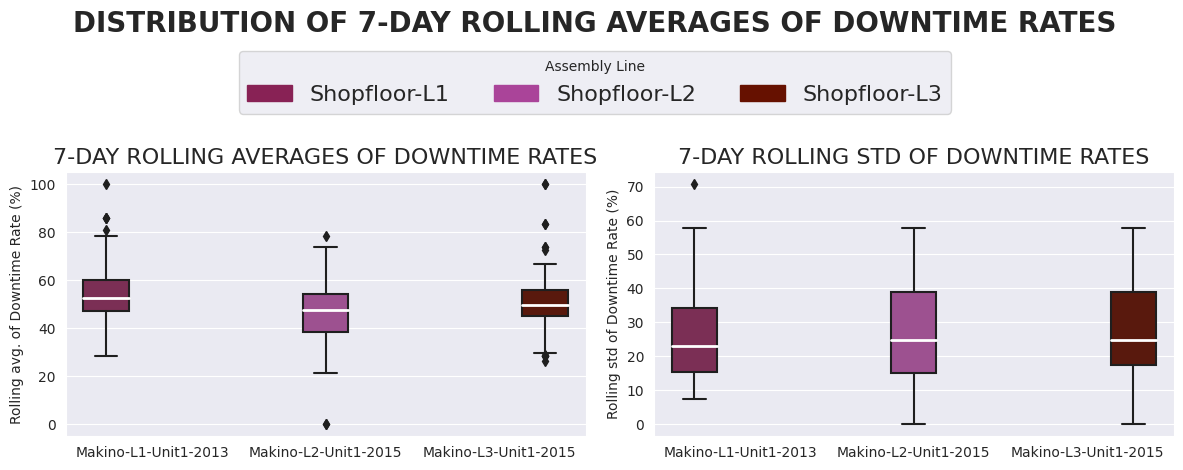

In [29]:
# Distribution of 7-day rolling averages of Downtime rates by machine

# Create subplots
fig, axes = plt.subplots(1, 2, sharey=False,figsize=(12, 5))

# Subplot 1: Timeline evolution
ax = axes[0]
sns.boxplot(
    data=downtime_per_date,
    x='Machine_ID',
    y='rolling_avg',
    hue='Machine_ID',
    palette=machine_downtime_color_map,
    #legend=False,
    medianprops={'color': 'white', 'linewidth': 2},  # Make the median line white and adjust its thickness
    ax=ax
)
ax.set_title(f"7-day rolling averages of downtime rates".upper(), fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Rolling avg. of Downtime Rate (%)')
ax.legend_.remove()  # Remove the legend explicitly

#ax.tick_params(axis='x', rotation=45)

# Subplot 2:  std
ax = axes[1]
sns.boxplot(
    data=downtime_per_date,
    x='Machine_ID',
    y='rolling_std',
    hue='Machine_ID',
    palette=machine_downtime_color_map,
    #legend=False,
    medianprops={'color': 'white', 'linewidth': 2},  # Make the median line white and adjust its thickness
    ax=ax
)
ax.set_title(f"7-day rolling std of downtime rates".upper(), fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Rolling std of Downtime Rate (%)')
ax.legend_.remove()  # Remove the legend explicitly
#ax.tick_params(axis='x', rotation=45)

# Add a shared legend
# Create a legend using the assembly_line_color_map
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in assembly_line_downtime_color_map.items()
]

# Place the legend below the subplots
fig.legend(
    handles=legend_patches,
    title='Assembly Line',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.75),
    ncol=3,
    frameon=True,
    fontsize=16
)

# Add an overall title
fig.suptitle(f"Distribution of 7-day rolling averages of downtime rates\n\n".upper(), weight='bold', fontsize=20)

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  
plt.show()

**Downtime Rate Analysis – Key Findings**

**Data Collection Pattern:** Readings showed irregular frequency, peaking and then declining (parabolic shape), but the distributions across machines remained similar.

**Failure Frequency:** Downtime was frequent, occurring almost every week, with only two weeks showing no incidents. Saturdays had a 100% downtime occurrence rate, while Wednesdays had the lowest (84%). However, downtime distribution by weekday varied across machines.

**Trend Over Time:** From February to June, downtime rates averaged around 50%, reflecting stable but significant downtime. Makino-L1-Unit1-2013 and Makino-L3-Unit1-2015 improved over time, ending below 50%, whereas Makino-L2-Unit1-2015 worsened, starting below 50% but consistently exceeding it later.

**Overall Downtime Comparison:** While daily rates distribution were very close, 7-day rolling averages reveal clearer differences which Makino-L1-Unit1-2013 (ShopFloor-L1) had the highest downtime (54%), followed by Makino-L3-Unit1-2015 (51%) and Makino-L2-Unit1-2015 (46%).



### Features Correlations with Downtime

The overall correlation heatmap, which includes all observations without separating by machine, shows no significant differences compared to the individual heatmaps for each machine. The key correlations with Downtime remain consistent across all cases, with Hydraulic Pressure, Cutting, Torque, and Spindle Speed being the most significant.

- **Hydraulic Pressure and Torque** exhibit moderate inverse correlations with Downtime (-0.56 and -0.41, respectively), indicating that their decrease is associated with increased downtime. 
- **Cutting Force** shows a moderate positive correlation with Downtime (0.45), suggesting that higher Cutting Force leads to more frequent downtime. 
- **Spindle Speed** has a weak positive correlation with Downtime (0.27), indicating that higher rotation rates are linked to increased downtime. 
- Additionally, **Cutting Force** is weakly correlated with **Spindle Speed** (0.23) and weakly inversely correlated with **Hydraulic Pressure** (-0.22). These findings highlight the significant and subtle relationships between these features and Downtime.

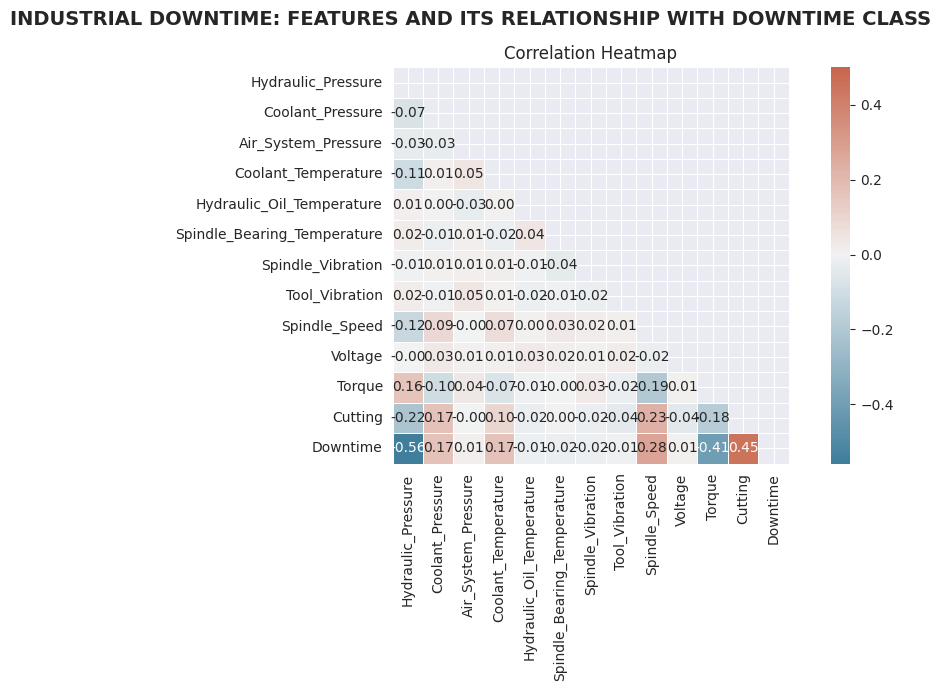

In [30]:
# Analyse the correlation with the class
corr_matrix = df[np.concatenate([numerical_col,['Downtime']])].corr(numeric_only=True)
np.fill_diagonal(corr_matrix.values, 0)  # Fill the diagonal with zeros
filtered_corr = corr_matrix[(abs(corr_matrix) > 0.15) & (corr_matrix != 1.0)]
filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Create a one-column subplot
fig, ax = plt.subplots(figsize=(10, 7))  # Adjust the size as needed

# Plot the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap, vmax=0.5, center=0, square=True, linewidths=0.5, ax=ax)

# Add titles
plt.suptitle("INDUSTRIAL DOWNTIME: FEATURES AND ITS RELATIONSHIP WITH DOWNTIME CLASS", weight='bold', fontsize=14)
plt.title('Correlation Heatmap', fontsize=12)

# Show the plot
plt.tight_layout()#(rect=[0, 0, 1, 0.96])  # Adjust layout to avoid overlap
plt.show()

In [31]:
# Correlations
from scipy.stats import skew, pearsonr, pointbiserialr, chi2_contingency, fisher_exact

def phi_coefficient(x, y):
    # Calculate the Phi coefficient (for binary vs binary correlation)
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape == (2, 2):  # Ensure it's a 2x2 contingency table
        return (confusion_matrix.iloc[0, 0] * confusion_matrix.iloc[1, 1] - 
                confusion_matrix.iloc[0, 1] * confusion_matrix.iloc[1, 0]) / np.sqrt(
            (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[0, 1]) * 
            (confusion_matrix.iloc[0, 0] + confusion_matrix.iloc[1, 0]) * 
            (confusion_matrix.iloc[1, 1] + confusion_matrix.iloc[0, 1]) * 
            (confusion_matrix.iloc[1, 1] + confusion_matrix.iloc[1, 0])
        )
    return None  # In case the matrix is not 2x2 (which shouldn't happen for binary variables)

def get_correlation_stats(data, col1, col2, significance_level=0.05):
    col1_dtype = data[col1].dtype
    col2_dtype = data[col2].dtype

    # Check if either column is binary
    def is_binary_col(col):
        return pd.api.types.is_numeric_dtype(col) and col.nunique() == 2

    # Handle binary vs binary columns with Phi coefficient
    if is_binary_col(data[col1]) and is_binary_col(data[col2]):
        stat = phi_coefficient(data[col1], data[col2])
        p_value = None 
        test_name = "Phi Coefficient"
        
    # Handle numeric vs. binary categorical columns with Point-Biserial correlation
    elif is_binary_col(data[col2]) and pd.api.types.is_numeric_dtype(col1_dtype):
        stat, p_value = pointbiserialr(data[col2], data[col1].astype(int))
        test_name = "Point-Biserial Correlation"
    
    # Handle binary categorical vs. numeric columns with Point-Biserial correlation
    elif is_binary_col(data[col1]) and pd.api.types.is_numeric_dtype(col2_dtype):
        stat, p_value = pointbiserialr(data[col1], data[col2].astype(int))
        test_name = "Point-Biserial Correlation"

    # Handle categorical vs. categorical columns with Chi-Square test
    elif pd.api.types.is_categorical_dtype(data[col1]) or pd.api.types.is_categorical_dtype(data[col2]):
        contingency_table = pd.crosstab(data[col1], data[col2])
        stat, p_value, _, _ = chi2_contingency(contingency_table)
        test_name = "Chi-Square Test"
        
    # Handle numeric vs. numeric columns with Pearson correlation
    elif pd.api.types.is_numeric_dtype(col1_dtype) and pd.api.types.is_numeric_dtype(col2_dtype) and not is_binary_col(data[col1]) and not is_binary_col(data[col2]):
        stat, p_value = pearsonr(data[col1], data[col2])
        test_name = "Pearson Correlation"
        
    else:
        # skip correlation test, a pairwise test is more suitable
        #raise ValueError("Column types not compatible for correlation analysis.")
        stat, p_value, test_name = (None, None, None)
        
    if (p_value == None):
        is_significant = True            
    elif (p_value < significance_level):
        is_significant = True
    else:
        is_significant = False
    
    return stat, p_value, test_name, is_significant

def get_correlations(data, column1, column2):
    stat, p_value, test_name, is_significant = get_correlation_stats(data, column1, column2, significance_level=0.05)
    results = []
    results.append({'Feature': column1, 'Target': column2, 'Type': test_name, 'is_siginificant':is_significant, 'Test Value': stat, 'P-Value': p_value})
    results_df = pd.DataFrame(results)
    return results_df

final_results = pd.DataFrame()
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Downtime', 'Hydraulic_Pressure')], ignore_index=True)
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Downtime', 'Cutting')], ignore_index=True)
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Downtime', 'Torque')], ignore_index=True)
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Downtime', 'Spindle_Speed')], ignore_index=True)
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Cutting', 'Spindle_Speed')], ignore_index=True)
final_results = pd.concat([final_results, get_correlations(df.dropna(), 'Cutting', 'Hydraulic_Pressure')], ignore_index=True)
final_results

,Feature,Target,Type,is_siginificant,Test Value,P-Value
0,Downtime,Hydraulic_Pressure,Point-Biserial Correlation,True,-0.552758,1.284848e-190
1,Downtime,Cutting,Point-Biserial Correlation,True,0.383990,1.661696e-84
2,Downtime,Torque,Point-Biserial Correlation,True,-0.406751,1.491058e-95
3,Downtime,Spindle_Speed,Point-Biserial Correlation,True,0.273018,5.733500e-42
4,Cutting,Spindle_Speed,Pearson Correlation,True,0.231764,2.107786e-30
5,Cutting,Hydraulic_Pressure,Pearson Correlation,True,-0.217178,8.207222e-27


### Features Distributions

**No Clear Distinction:** Features like Air_System_Pressure, Hydraulic_Oil_Temperature, Spindle_Bearing_Temperature, Spindle_Vibration, Tool_Vibration, and Voltage show nearly identical KDE distributions for both normal operations and failures, indicating they are not strong differentiators of downtime.

**Distinct Patterns in Downtime:** Hydraulic_Pressure, Coolant_Pressure, Coolant_Temperature, Spindle_Speed, Torque, and Cutting exhibit noticeable differences between normal and downtime conditions, with most showing bimodal distributions. Their KDE curves suggest specific value ranges associated with downtime, aligning with the correlations found above.


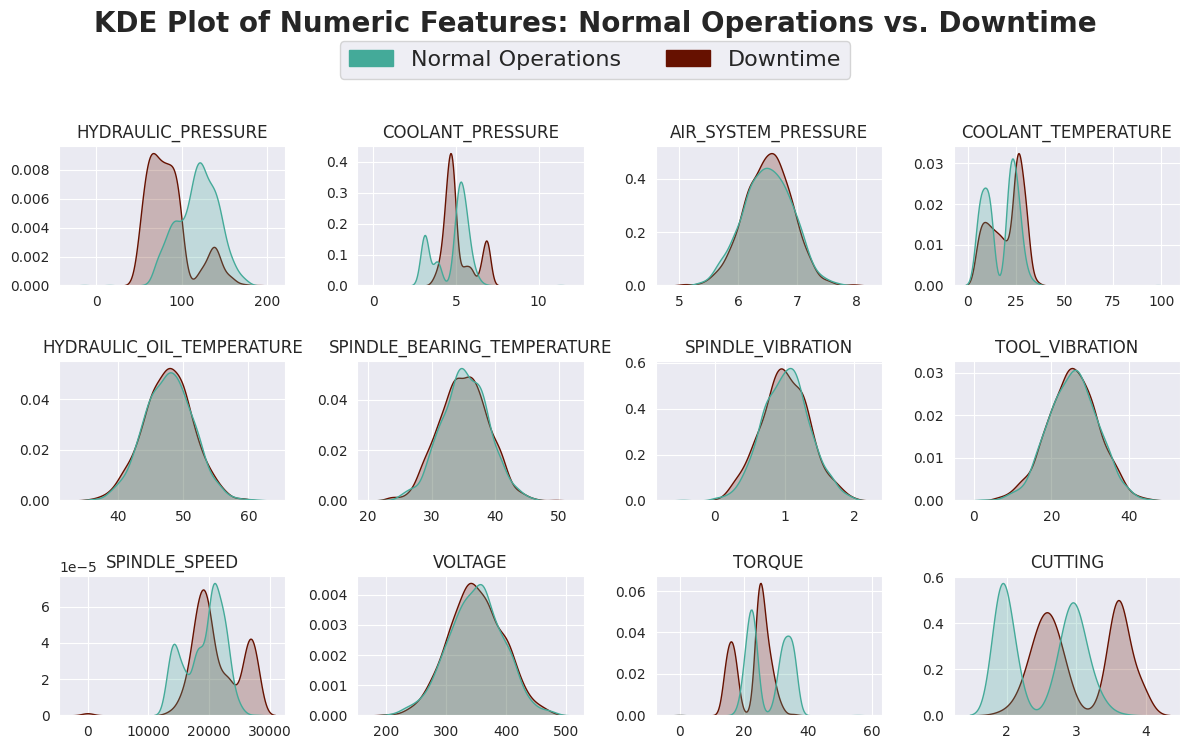

In [32]:
# Numeric feature distribution across Downtime-status
import math
downtime_palette = {0: palette[2], 1: palette[9]}

n_cols = 4
n_rows = math.ceil(len(numerical_col) / n_cols)  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharey=False)  
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each numerical column and plot
for i, column in enumerate(numerical_col):
    sns.kdeplot(data=df, x=column, hue='Downtime', shade=True, legend=False, palette=downtime_palette, ax=axes[i])
    axes[i].set_title(f'{column}'.upper())
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

# Hide empty subplots if any
for i in range(len(numerical_col), len(axes)):
    fig.delaxes(axes[i])  

# Add a shared legend
legend_dict = {"Normal Operations": palette[2], "Downtime": palette[9]}
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.88),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('KDE Plot of Numeric Features: Normal Operations vs. Downtime\n', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**Operational Consistency Across Machines**

The confidence intervals for each feature, grouped by machine and operational status, show that variations are generally less than 1 unit in most cases. This indicates that, overall, all three machines operate in a similar manner.

The features where the standard deviation of the confidence interval (CI) bounds across machines exceeds 1 unit are:

- Hydraulic Pressure (up to 1.36 bar)
- Voltage (up to 2.64 volts)
- Spindle Speed (up to 144 RPM)

However, when comparing these variations to the overall statistical distribution of these features, even the largest differences are not significant enough to justify analyzing feature distributions separately for each machine. Therefore, an overall analysis by downtime status is sufficient.

In [33]:
# Comparing the standard deviation of CI bounds across machines to determine if per-machine analysis is necessary.

# Placeholder function for confidence interval calculation
def calc_upper_lower_whiskers(df, col, confidence=0.95):
    """Calculate confidence interval for a given numerical column."""
    mean = df[col].mean()
    std_err = df[col].std() / np.sqrt(len(df))
    margin = 1.96 * std_err  # Approximate 95% CI
    return (mean - margin, mean + margin)

# Filtering Normal Operation (Downtime == 0) and Downtime cases (Downtime == 1)
normal_op = df[df['Downtime'] == 0]
downtime_op = df[df['Downtime'] == 1]

results = []

# Loop through numerical features
for column in numerical_col:
    for downtime_status, subset in [('Normal', normal_op), ('Downtime', downtime_op)]:
        ci_min = []
        ci_max = []
        
        # Compute CI for each machine
        for machine in df['Machine_ID'].unique():
            machine_data = subset[subset['Machine_ID'] == machine]
            if not machine_data.empty:
                lower, upper = calc_upper_lower_whiskers(machine_data, column)
                ci_min.append(lower)
                ci_max.append(upper)
        
        # Compute standard deviation of min/max confidence interval bounds
        std_min = np.std(ci_min) if len(ci_min) > 1 else np.nan
        std_max = np.std(ci_max) if len(ci_max) > 1 else np.nan
        
        results.append([column, downtime_status, std_min, std_max])

print("standard deviation of CI bounds across machines and operational status greater than 1 unit: ".upper())
std_df = pd.DataFrame(results, columns=["Feature", "Downtime Status", "Std of CI Min", "Std of CI Max"])
std_df[std_df['Std of CI Min'] > 1]

STANDARD DEVIATION OF CI BOUNDS ACROSS MACHINES AND OPERATIONAL STATUS GREATER THAN 1 UNIT: 


,Feature,Downtime Status,Std of CI Min,Std of CI Max
0,Hydraulic_Pressure,Normal,1.311267,1.356009
16,Spindle_Speed,Normal,26.501543,29.309653
17,Spindle_Speed,Downtime,144.133086,115.359998
18,Voltage,Normal,2.628182,2.492270


#### Pressure Analysis
**Hydraulic Pressure**

- The distribution and statistical test indicate significant differences between normal operations and failures. The Mann-Whitney U test resulted in a large effect size of 0.65, strongly suggesting that lower hydraulic pressure generally leads to downtime. Additionally, unusually high hydraulic pressure may also contribute to failures.

- Negative values during normal operations likely indicate measurement errors rather than gauge pressure (which is relative to atmospheric pressure).

- During normal operations, the average hydraulic pressure is 118.6 bars, whereas during downtime, it drops to 84.8 bars.

**Coolant Pressure**

- The distribution and statistical test do not indicate significant differences between operational statuses, as the interquartile ranges overlap.

- Extremely high values reaching 11.4 bars suggest measurement errors, as the upper bound remains below 8 bars in both normal and downtime conditions.

- Conversely, extremely low values during downtime (0.32 bar) suggest a loss of pressure.
  
- During normal operations, the average Coolant Pressure is 4.8 bars, and it slightly increases to 5.11 bars during downtime.
  
**Air System Pressure**

Average and median are consistent at 6.5 bars during both normal operations and downtime, with no significant differences between operational statuses.

In [34]:
# Numerical features stats during normal operations (No Downtime)
#print("Numerical features stats during normal operations (No Downtime):\n".upper())
#df.groupby(['Downtime'])[numerical_col[0:3]].agg([np.mean, np.median, min, max]).transpose()

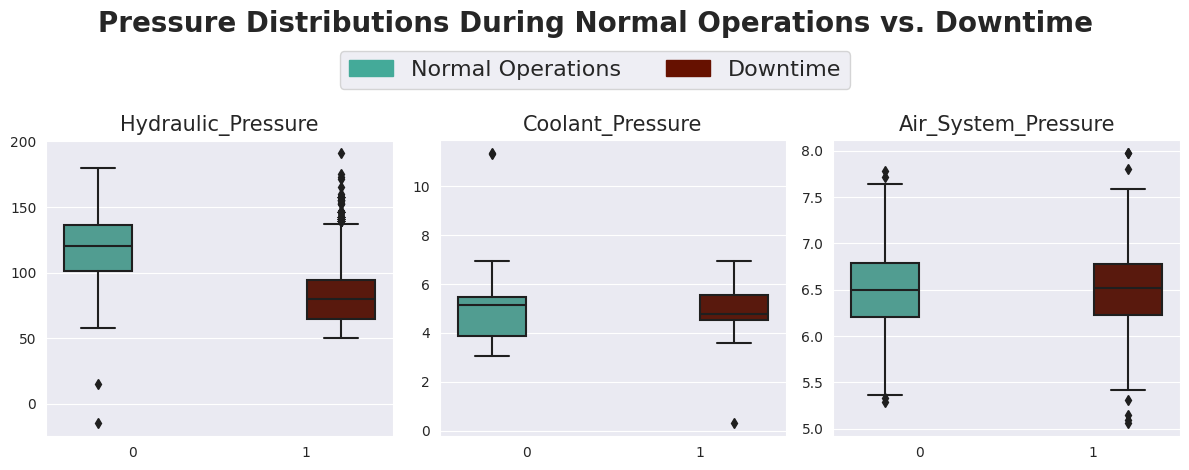

In [35]:
# Distributions of features on normal operations and during downtime 
numerical_col = df.select_dtypes(include='number').columns[:12]  # Adjust to ensure it's 12 features

# Create subplots with 3 columns and 4 rows (or adjust the grid as needed)
rows, cols = 1, 3
fig, axes = plt.subplots(rows, cols, sharey=False,figsize=(12, 5), constrained_layout=True)

axes = axes.flatten()

for i, col in enumerate(numerical_col[0:3]):
    sns.boxplot(data=df ,x='Downtime', y=col, ax=axes[i], hue='Downtime', palette=downtime_palette)
    axes[i].set_title(col, fontsize=15)
    axes[i].set_ylabel('')  # Remove y-axis label to reduce clutter
    axes[i].set_xlabel('')  # Remove x-axis label to reduce clutter
    axes[i].legend_.remove()  # Remove the legend explicitly

# Hide any unused subplots
for i in range(len(numerical_col), len(axes)):
    axes[i].axis('off')

# Add a shared legend
legend_dict = {"Normal Operations": palette[2], "Downtime": palette[9]}
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.8),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('Pressure Distributions During Normal Operations vs. Downtime\n', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [36]:
# Pairwise tests and Mann-Whitney U test effect size	
final_results = pd.DataFrame()
for column in numerical_col[0:3]:
    parcial = pairwise_test_two_groups(df, groupby_column='Downtime', target_column=column, extra_text='Normal vs Dowtime')
    final_results = pd.concat([final_results, parcial], ignore_index=True)
final_results#.sort_values(by='is_siginificant', ascending=False)

,Feature,Target,Type,is_siginificant,Test Value,P-Value,Effect Size,Effect Size Test
0,Normal vs Dowtime,Hydraulic_Pressure,Mann-Whitney U test,True,264133.0,2.446991e-178,0.659109,Mann-Whitney U Effect Size
1,Normal vs Dowtime,Coolant_Pressure,Mann-Whitney U test,False,763319.0,7.450217e-01,0.007542,Mann-Whitney U Effect Size
2,Normal vs Dowtime,Air_System_Pressure,Mann-Whitney U test,False,779418.0,6.191993e-01,0.018422,Cohen's d


#### Temperature Analysis

**Coolant Temperature**

- Although the distribution does not indicate significant differences between operational statuses— as the interquartile ranges overlap and the means and medians do not differ greatly— the Mann-Whitney U test resulted in a small-to-moderate effect size of -0.24, suggesting that the two distributions are somewhat different, but the shift is not substantial. This implies that higher Coolant Temperature may occasionally contribute to downtime.

- Extremely high values reaching 98°C suggest measurement errors, as the upper bound remains below 40°C in both normal and downtime conditions.

- During normal operations, the average Coolant Temperature is 17°C, increasing slightly to about 20°C during downtime.

**Hydraulic Oil Temperature**

Average and median are stable around 47.6°C, with no significant differences between operational statuses.

**Spindle Bearing Temperature**

Average and median remain consistent around 35°C during both conditions, with no significant differences between operational statuses.

In [37]:
# Numerical features stats during normal operations (No Downtime)
#print("Numerical features stats during normal operations (No Downtime):\n".upper())
#df.groupby(['Downtime'])[numerical_col[3:6]].agg([np.mean, np.median, min, max]).transpose()

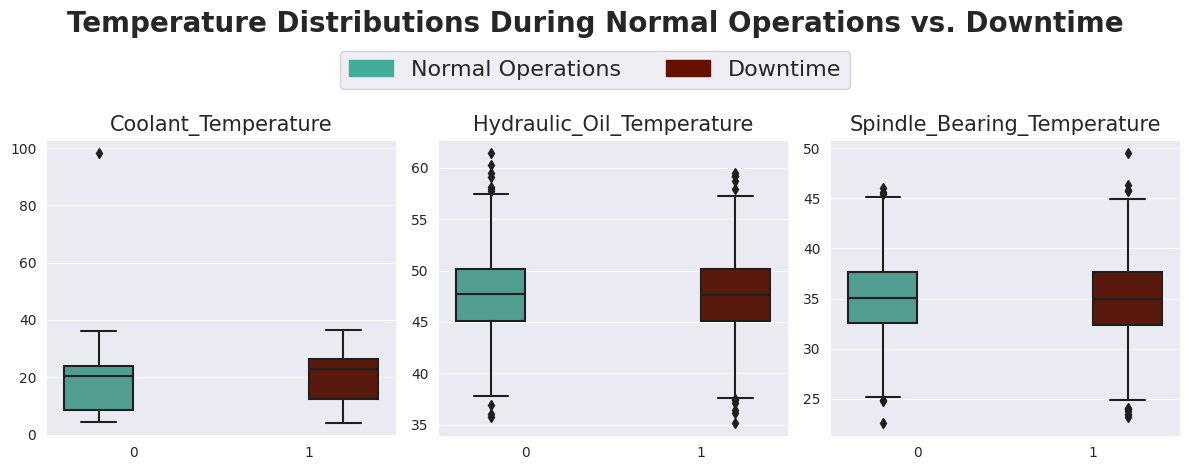

In [38]:
# Distributions of features on normal operations and during downtime 
fig, axes = plt.subplots(rows, cols, sharey=False,figsize=(12, 5), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(numerical_col[3:6]):
    sns.boxplot(data=df ,x='Downtime', y=col, ax=axes[i], hue='Downtime', palette=downtime_palette)
    axes[i].set_title(col, fontsize=15)
    axes[i].set_ylabel('')  # Remove y-axis label to reduce clutter
    axes[i].set_xlabel('')  # Remove x-axis label to reduce clutter
    axes[i].legend_.remove()  # Remove the legend explicitly

# Hide any unused subplots
for i in range(len(numerical_col), len(axes)):
    axes[i].axis('off')

# Add a shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.8),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('Temperature Distributions During Normal Operations vs. Downtime\n', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [39]:
# Pairwise tests and Mann-Whitney U test effect size	
final_results = pd.DataFrame()
for column in numerical_col[3:6]:
    parcial = pairwise_test_two_groups(df, groupby_column='Downtime', target_column=column, extra_text='Normal vs Dowtime')
    final_results = pd.concat([final_results, parcial], ignore_index=True)
final_results#.sort_values(by='is_siginificant', ascending=False)

,Feature,Target,Type,is_siginificant,Test Value,P-Value,Effect Size,Effect Size Test
0,Normal vs Dowtime,Coolant_Temperature,Mann-Whitney U test,True,958832.0,4.402521e-25,-0.239526,Mann-Whitney U Effect Size
1,Normal vs Dowtime,Hydraulic_Oil_Temperature,Mann-Whitney U test,False,763021.5,6.504385e-01,-0.025289,Cohen's d
2,Normal vs Dowtime,Spindle_Bearing_Temperature,Mann-Whitney U test,False,757985.5,2.964699e-01,-0.038938,Cohen's d


#### Vibration and Speed Analysis

**Spindle Vibration**

- The distribution and statistical test do not indicate significant differences between operational statuses.

- There are negative values; however, since Spindle Vibration can have negative readings depending on the measurement method, it is essential to verify sensor specifications and measurement units to determine whether these values are expected or indicate data collection issues.

- The average and median remain around 1.0 micrometer in both normal and downtime conditions.

**Tool Vibration**

- The distribution and statistical test do not indicate significant differences between operational statuses. 
- The average remain around 25 micrometers, in both normal and downtime conditions.


**Spindle Speed**

- The distribution and statistical test indicate significant differences between normal operations and failures. The Mann-Whitney U test resulted in the Mann-Whitney U test resulted in a small-to-moderate effect size of -0.24 which suggests that higher Spindle Speed may occasionally contribute to downtime.

- During normal operations, the average Spindle Speed is 27,882 RPM, whereas during downtime, it increases slightly by approximately 2,114.9 RPM.

In [40]:
# Numerical features stats during normal operations (No Downtime)
#print("Numerical features stats during normal operations (No Downtime):\n".upper())
#df.groupby(['Downtime'])[numerical_col[6:9]].agg([np.mean, np.median, min, max]).transpose()

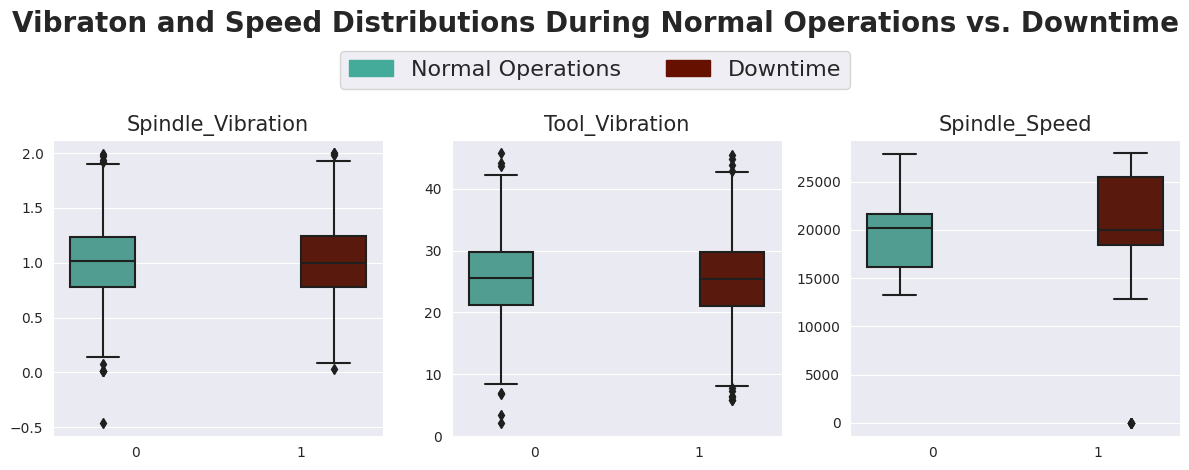

In [41]:
# Distributions of features on normal operations and during downtime 
fig, axes = plt.subplots(rows, cols, sharey=False,figsize=(12, 5), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(numerical_col[6:9]):
    sns.boxplot(data=df ,x='Downtime', y=col, ax=axes[i], hue='Downtime', palette=downtime_palette)
    axes[i].set_title(col, fontsize=15)
    axes[i].set_ylabel('')  # Remove y-axis label to reduce clutter
    axes[i].set_xlabel('')  # Remove x-axis label to reduce clutter
    axes[i].legend_.remove()  # Remove the legend explicitly

# Hide any unused subplots
for i in range(len(numerical_col), len(axes)):
    axes[i].axis('off')

# Add a shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.8),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('Vibraton and Speed Distributions During Normal Operations vs. Downtime\n', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [42]:
# Pairwise tests and Mann-Whitney U test effect size	
final_results = pd.DataFrame()
for column in numerical_col[6:9]:
    parcial = pairwise_test_two_groups(df, groupby_column='Downtime', target_column=column, extra_text='Normal vs Dowtime')
    final_results = pd.concat([final_results, parcial], ignore_index=True)
final_results#.sort_values(by='is_siginificant', ascending=False)

,Feature,Target,Type,is_siginificant,Test Value,P-Value,Effect Size,Effect Size Test
0,Normal vs Dowtime,Spindle_Vibration,Mann-Whitney U test,False,759290.0,4.038462e-01,-0.033324,Cohen's d
1,Normal vs Dowtime,Tool_Vibration,Mann-Whitney U test,False,769848.5,8.045469e-01,-0.011773,Cohen's d
2,Normal vs Dowtime,Spindle_Speed,Mann-Whitney U test,True,963641.0,3.617680e-25,-0.239661,Mann-Whitney U Effect Size


#### Voltage, Torque and Cutting Force Analysis

**Voltage**

- The distribution and statistical test do not indicate significant differences between operational statuses.
- The average remained around 349 Volts, in both normal and downtime conditions.

**Torque**

- The distribution and statistical test indicate differences between normal operations and failures. The Mann-Whitney U test resulted in a medium effect size of 0.33, impling that lower Torque generally lead to downtime. 
  
-  Extremely high values reaching 55 Nm suggest measurement errors, as the upper bound remains below 40 Nm in both normal and downtime conditions. Stoppages are present in both normal and downtime conditions which raises questions about sensor reliability or whether these values reflect dynamic machine behavior.

- During normal operations, the average Torque is 27.8 PM, whereas during downtime, it drops to 22 Nm.

**Cutting Force**

- The distribution and statistical test indicate differences between normal operations and failures. The Mann-Whitney U test resulted in a medium effect size of -0.45, impling that higher Cutting Force generally lead to downtime.

- During normal operations, the average utting Force is 2.50 kN, whereas during downtime, increases slightly to 3.06 kN.

In [43]:
# Numerical features stats during normal operations (No Downtime)
#print("Numerical features stats during normal operations (No Downtime):\n".upper())
#df.groupby(['Downtime'])[numerical_col[9:12]].agg([np.mean, np.median, min, max]).transpose()

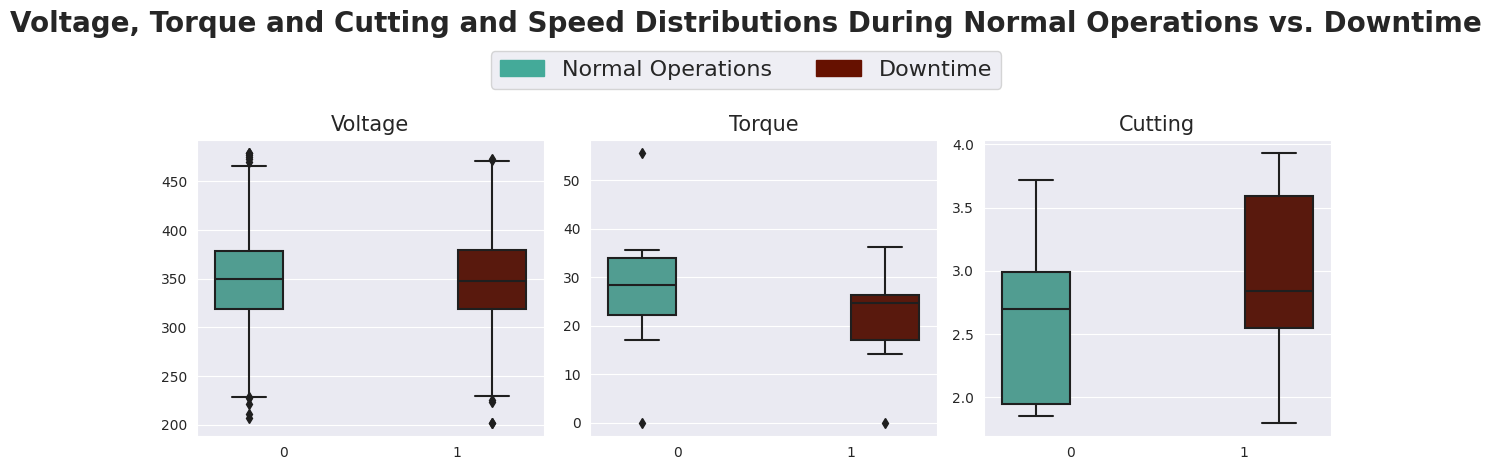

In [44]:
# Distributions of features on normal operations and during downtime 
fig, axes = plt.subplots(rows, cols, sharey=False,figsize=(12, 5), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(numerical_col[9:12]):
    sns.boxplot(data=df ,x='Downtime', y=col, ax=axes[i], hue='Downtime', palette=downtime_palette)
    axes[i].set_title(col, fontsize=15)
    axes[i].set_ylabel('')  # Remove y-axis label to reduce clutter
    axes[i].set_xlabel('')  # Remove x-axis label to reduce clutter
    axes[i].legend_.remove()  # Remove the legend explicitly

# Hide any unused subplots
for i in range(len(numerical_col), len(axes)):
    axes[i].axis('off')

# Add a shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.8),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('Voltage, Torque and Cutting and Speed Distributions During Normal Operations vs. Downtime\n', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [45]:
# Pairwise tests and Mann-Whitney U test effect size	
final_results = pd.DataFrame()
for column in numerical_col[9:12]:
    parcial = pairwise_test_two_groups(df, groupby_column='Downtime', target_column=column, extra_text='Normal vs Dowtime')
    final_results = pd.concat([final_results, parcial], ignore_index=True)
final_results#.sort_values(by='is_siginificant', ascending=False)

,Feature,Target,Type,is_siginificant,Test Value,P-Value,Effect Size,Effect Size Test
0,Normal vs Dowtime,Voltage,Mann-Whitney U test,False,778171.0,9.632665e-01,0.011702,Cohen's d
1,Normal vs Dowtime,Torque,Mann-Whitney U test,True,514141.5,4.337799e-46,0.330583,Mann-Whitney U Effect Size
2,Normal vs Dowtime,Cutting,Mann-Whitney U test,True,1124503.5,1.779640e-83,-0.447713,Mann-Whitney U Effect Size


**Feature Distributions & Downtime Correlations**

The strongest correlations with Downtime were observed in Hydraulic Pressure, Cutting Force, Torque, and Spindle Speed, with noticeable bimodal distributions. Most of other features followed a normal distribution and showed significant overlap, indicating no distinction between operational statuses.

Statistical tests confirmed key distinctions:

- Hydraulic Pressure → Large effect size (0.65), strongly suggesting that lower pressure leads to downtime.
- Torque → Medium effect size (0.33), indicating lower torque is associated with downtime.
- Cutting Force → Medium effect size (-0.45), suggesting higher cutting force contributes to downtime.
- Coolant Temperature & Spindle Speed → Small-to-moderate effect sizes, implying that higher values may occasionally contribute to downtime.
- Coolant Pressure → No significant difference between operational statuses.

**Sensor Reliability & Measurement Anomalies**

- Several potential measurement errors were identified, including negative values, extreme highs, and values near zero.
- Spindle Vibration, Tool Vibration, and Torque often show near-zero readings, raising concerns about sensor reliability.
- These anomalies could result from cyclic machine behavior, such as pauses in rotation or inactive components.

## Predicting Machine Failures

The goal is to predict downtime based on historic values from sensor readings patterns of machine normal operations and during failures and enable proactive measures to minimize interruptions. Therefore, this is a classification problem.

### Preprocessing

**Flagging potential errors:** Setting extreme values far beyond the upper whiskers and negative values to NaN. Further investigation is needed to distinguish between true sensor errors and meaningful rare events to validate this step.

**Handling missing data:** Filling missing values using the median, grouped by Machine and Operational Status.


In [46]:
# Flagging potential errors and Handling missing data
df.loc[(df['Hydraulic_Pressure'] < 0), 'Hydraulic_Pressure'] = np.nan
df.loc[(df['Spindle_Vibration'] < 0), 'Spindle_Vibration'] = np.nan
df.loc[(df['Coolant_Pressure'] > 8), 'Coolant_Pressure'] = np.nan
df.loc[(df['Coolant_Temperature'] > 60), 'Coolant_Temperature'] = np.nan
df.loc[(df['Torque'] > 50), 'Torque'] = np.nan

# Fill missing data based on median values grouped by Machine and Operational status
df[numerical_col] = df.groupby(['Machine_ID', 'Downtime'])[numerical_col].transform(lambda x: x.fillna(x.median()))

df.drop(columns=[ 'Assembly_Line_No', 'Week', 'Date','Machine_ID', 'Week_Of_Year', 'Month_Year', 'Ordinal_Week', 'Month', 'Year'], inplace=True)

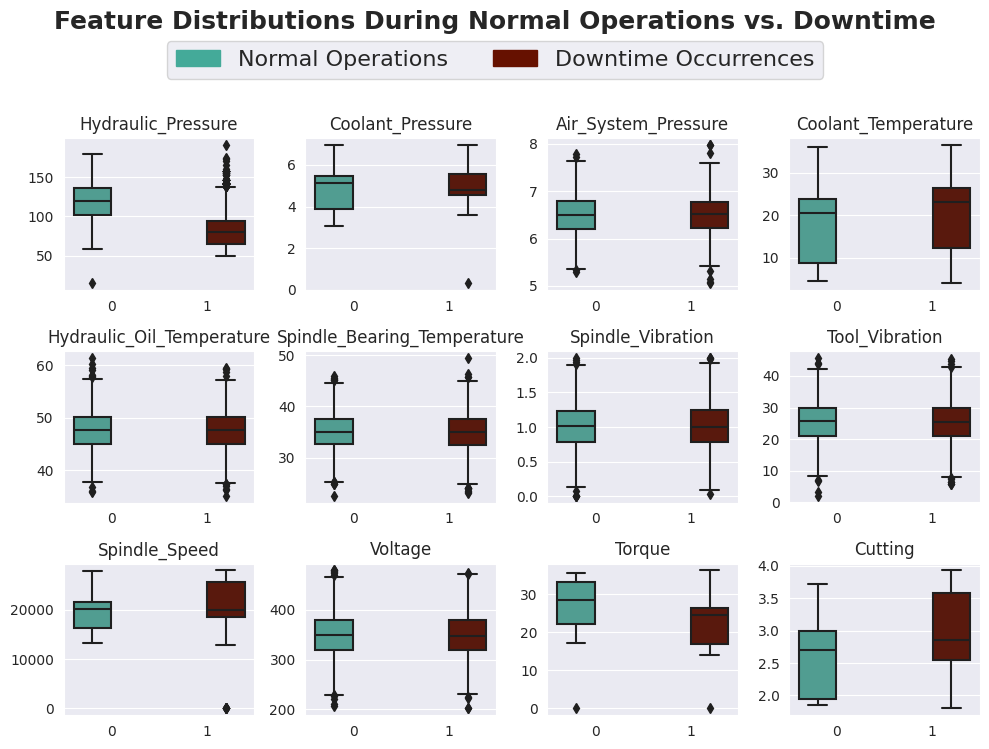

In [47]:
# Distributions of features on normal operations and during downtime 
numerical_col = df.select_dtypes(include='number').columns[:12]  # Adjust to ensure it's 12 features

# Create subplots with 3 columns and 4 rows (or adjust the grid as needed)
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, sharey=False,figsize=(10, 8), constrained_layout=True)

downtime_palette = {0: palette[2], 1: palette[9]}
axes = axes.flatten()

for i, col in enumerate(numerical_col):
    sns.boxplot(data=df ,x='Downtime', y=col, ax=axes[i], hue='Downtime', palette=downtime_palette)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')  # Remove y-axis label to reduce clutter
    axes[i].set_xlabel('')  # Remove x-axis label to reduce clutter
    axes[i].legend_.remove()  # Remove the legend explicitly

# Hide any unused subplots
for i in range(len(numerical_col), len(axes)):
    axes[i].axis('off')

# Add a shared legend
legend_dict = {"Normal Operations": palette[2], "Downtime Occurrences": palette[9]}
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=key) 
    for key, color in legend_dict.items()
]
fig.legend(
    handles=legend_patches,
    title='',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.88),
    ncol=2,
    frameon=True,
    fontsize=16
)

fig.suptitle('Feature Distributions During Normal Operations vs. Downtime\n', fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Training and Evaluation
The model should minimize both false positives and false negatives to reduce unnecessary machine stoppages while proactively detecting real downtimes. Therefore, the primary evaluation metrics are F1-score and Precision-Recall AUC (PR-AUC), ensuring a balance between:  

- Precision → Avoiding false alarms (unnecessary machine stops).  
- Recall → Detecting actual downtimes (preventing failures).  

To compare different approaches, we evaluate two models:  
1. A baseline Logistic Regression model.  
2. A tree-based XGBoost Classifier.  

Since the binary class distribution is roughly balanced, the dataset was partitioned into 70% training and 30% testing. The training process was assessed using 5-fold cross-validation and evaluated using Precision-Recall AUC, which emphasizes the trade-off between precision and recall, making it more suitable.

The model was trained using the following features: Hydraulic_Pressure, Coolant_Pressure, Air_System_Pressure, Coolant_Temperature, Hydraulic_Oil_Temperature, Spindle_Bearing_Temperature, Spindle_Vibration, Tool_Vibration, Spindle_Speed, Voltage, Torque, Cutting, and Day_of_Week.

Since the machines operate similarly, Machine_ID and Assembly_Line_No were excluded. Additionally, date information was not included due to the absence of timestamps and the presence of gaps, making a time-series analysis unfeasible.

To further enhance predictive maintenance, incorporating timestamp data, time-series feature engineering, and anomaly detection could improve early failure detection and proactive interventions.

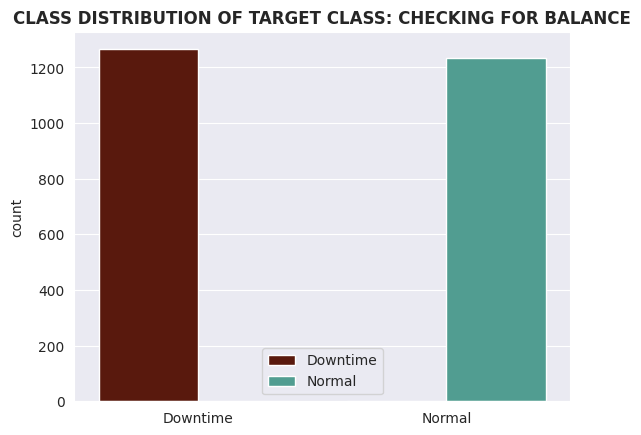

In [48]:
# Class Distribution
downtime_palette_cat = {'Normal': '#44AA99', 'Downtime': '#661100'}
data_plot = df[['Downtime']]
data_plot['Downtime_cat'] = data_plot['Downtime'].replace({0: 'Normal', 1: 'Downtime'})

sns.countplot(data=data_plot, x="Downtime_cat", hue="Downtime_cat", palette=downtime_palette_cat)

plt.legend(title='')
plt.title("Class Distribution of Target Class: Checking for Balance".upper(), weight='bold')
plt.xlabel("")
plt.show()

In [49]:
# Preparing data 
from sklearn.model_selection import train_test_split

#df_ml = pd.get_dummies (df, columns=['Assembly_Line_No'], drop_first=True, prefix='')
#df_ml['_Shopfloor-L1'] = df_ml['_Shopfloor-L1'].astype(int)
#df_ml['_Shopfloor-L2'] = df_ml['_Shopfloor-L2'].astype(int)
#df_ml['_Shopfloor-L3'] = df_ml['_Shopfloor-L3'].astype(int)

#df_ml['Month'] = df_ml['Month'].astype(int)
#df_ml['Year'] = df_ml['Year'].astype(int)



# Splitting data training and testing
features = df.drop(columns=['Downtime'])
target = df[['Downtime']].values

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=SEED)

X_test_with_dates = X_test.copy()
X_train = X_train.drop(columns=['Day'])
X_test = X_test.drop(columns=['Day'])

print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1750 entries, 652 to 2385
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Hydraulic_Pressure           1750 non-null   float64
 1   Coolant_Pressure             1750 non-null   float64
 2   Air_System_Pressure          1750 non-null   float64
 3   Coolant_Temperature          1750 non-null   float64
 4   Hydraulic_Oil_Temperature    1750 non-null   float64
 5   Spindle_Bearing_Temperature  1750 non-null   float64
 6   Spindle_Vibration            1750 non-null   float64
 7   Tool_Vibration               1750 non-null   float64
 8   Spindle_Speed                1750 non-null   float64
 9   Voltage                      1750 non-null   float64
 10  Torque                       1750 non-null   float64
 11  Cutting                      1750 non-null   float64
 12  Day_Of_Week                  1750 non-null   int32  
dtypes: float64(12), int32

The tree-based XGBoost Classifier outperformed the baseline Logistic Regression model, achieving a higher average Precision-Recall AUC (PR-AUC) of 0.991 compared to 0.899 during training. The PR-AUC distribution from 5-fold cross-validation was more consistent for XGBoost, with all values above 0.97, whereas Logistic Regression exhibited a larger interquartile range, wider confidence intervals, and values reaching up to 0.927.

On the test set, XGBoost misclassified only 1 instance as a false negative (0.3% of actual downtime observations). In contrast, Logistic Regression misclassified 17.4% of observations with no downtime and 18.8% of actual downtime cases, resulting in an F1-score of up to 82% per class.

XGBoost further demonstrated superior performance with a PR-AUC of 1.00 and an accuracy of 99.9%, compared to a PR-AUC of 0.898 and an accuracy of 81.9% for Logistic Regression.

These results indicate that the XGBoost model is significantly more effective in predicting machine downtime based on the available features. The data were neither scaled nor normalized, and further improvements could be achieved through hyperparameter tuning and feature selection to enhance model performance.

In [50]:
# LogisticRegression: logreg_classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# Perform 5-fold Cross-Validation on the training set
logreg_classifier = LogisticRegression(random_state=SEED)
cv_results_logreg = cross_val_score(logreg_classifier, X_train, y_train, cv=5, scoring='average_precision')
print(f"Training Mean 5-CV PR-AUC: {cv_results_logreg.mean():.4f}")

# Predict on the test set
logreg_classifier.fit(X_train, y_train)
y_pred_logreg = logreg_classifier.predict(X_test)
lr_confusion_matrix = confusion_matrix(y_test, y_pred_logreg)

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_logreg, digits=3))

Training Mean 5-CV PR-AUC: 0.9017
Classification Report on Test Set:
              precision    recall  f1-score   support

           0      0.813     0.815     0.814       368
           1      0.822     0.819     0.820       382

    accuracy                          0.817       750
   macro avg      0.817     0.817     0.817       750
weighted avg      0.817     0.817     0.817       750



In [51]:
# XGBClassifier model: xgb_classifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score

# Convert the training and testing sets into DMatrixes: DM_train, DM_test
DM_train = xgb.DMatrix(X_train, y_train)

# Perform cross-validation: cv_results
params = {"objective":"binary:logistic"}
cv_results_xgb = xgb.cv(dtrain=DM_train, params=params, 
                  nfold=5, num_boost_round=5, 
                  metrics="aucpr", as_pandas=True, seed=SEED)

# Print cv_results
#print(cv_results)
print(f"Training Mean 5-CV PR-AUC: {cv_results_xgb['train-aucpr-mean'].mean():.4f}")

# Predict on the test set
xgb_classifier = xgb.XGBClassifier(objective=params["objective"], seed=SEED)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)

xgb_confusion_matrix = confusion_matrix(y_test, y_pred_xgb)

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_xgb, digits=3))


Training Mean 5-CV PR-AUC: 0.9915
Classification Report on Test Set:
              precision    recall  f1-score   support

           0      0.997     1.000     0.999       368
           1      1.000     0.997     0.999       382

    accuracy                          0.999       750
   macro avg      0.999     0.999     0.999       750
weighted avg      0.999     0.999     0.999       750



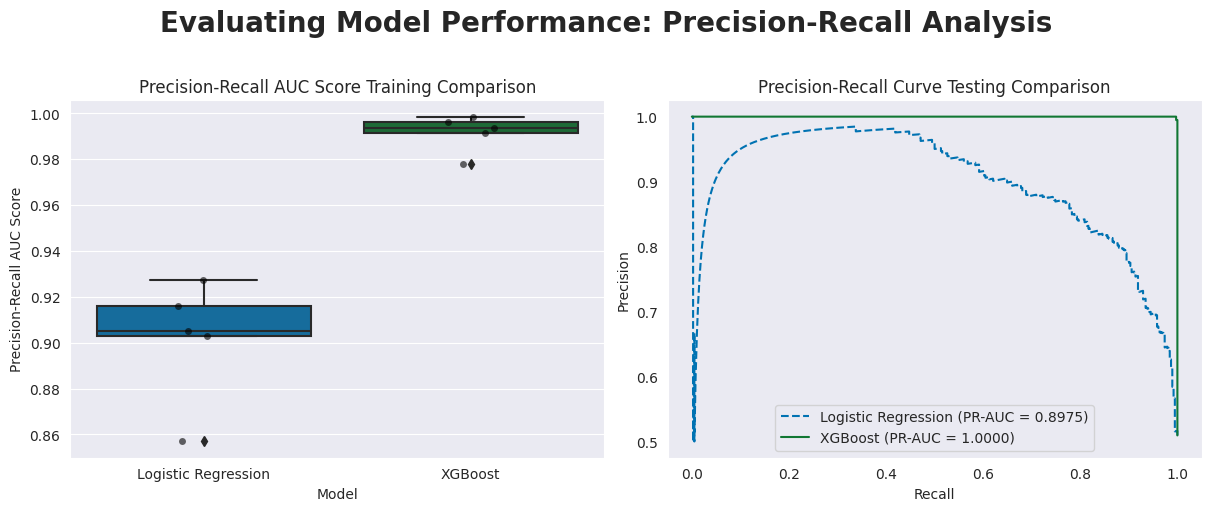

In [52]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall AUC DataFrame for Boxplot
auc_df = pd.DataFrame({
    "Precision-Recall AUC Score": np.concatenate([cv_results_logreg, cv_results_xgb['train-aucpr-mean']]),
    "Model": ["Logistic Regression"] * len(cv_results_logreg) + ["XGBoost"] * len(cv_results_xgb),
    "Fold": list(range(1, len(cv_results_logreg) + 1)) + list(range(1, len(cv_results_xgb) + 1))
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

### 📌 **Subplot 1: PR-AUC Scores (Boxplot & Stripplot)**
ax = axes[0]
sns.boxplot(x="Model", y="Precision-Recall AUC Score", data=auc_df, palette=[palette[-1], palette[3]], ax=ax)
sns.stripplot(x="Model", y="Precision-Recall AUC Score", data=auc_df, color="black", alpha=0.6, jitter=True, ax=ax)

ax.set_title("Precision-Recall AUC Score Training Comparison")
ax.set_ylabel("Precision-Recall AUC Score")
ax.set_xlabel("Model")

### 📌 **Subplot 2: Precision-Recall Curve**
ax = axes[1]

y_prob_logreg = logreg_classifier.predict_proba(X_test)[:, 1]  # Get probability scores
y_prob_xgb = xgb_classifier.predict_proba(X_test)[:, 1]  # Get probability scores

# Compute Precision-Recall Curve and PR-AUC for Logistic Regression
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_prob_logreg)
pr_auc_logreg = average_precision_score(y_test, y_prob_logreg)

# Compute Precision-Recall Curve and PR-AUC for XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

ax.plot(recall_logreg, precision_logreg, label=f'Logistic Regression (PR-AUC = {pr_auc_logreg:.4f})', linestyle='--', color=palette[-1])
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.4f})', linestyle='-', color=palette[3])

# Labels & Legend
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Testing Comparison")
ax.legend(loc="lower center")
ax.grid()

fig.suptitle('Evaluating Model Performance: Precision-Recall Analysis\n', fontsize=20, weight='bold')

plt.show()


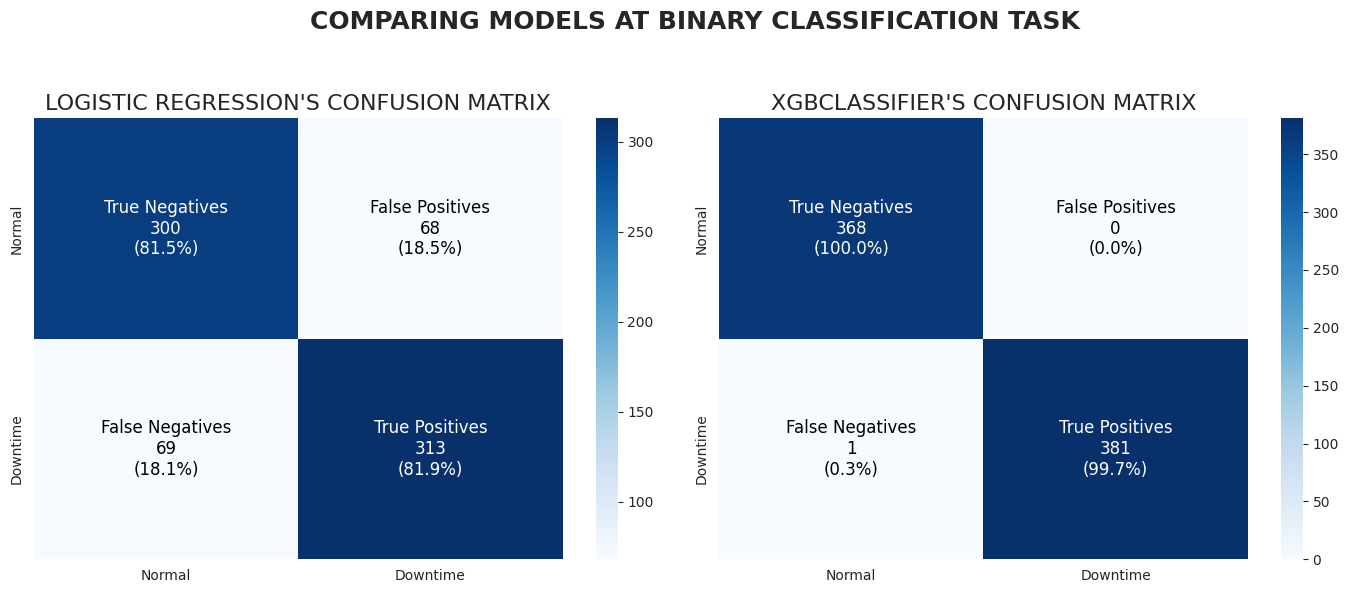

In [53]:
# Model Evaluation

# Function to annotate heatmap with counts, percentages by class, and custom labels
def annotate_heatmap(matrix, ax, title, cell_labels=None):
    # Normalize matrix by row to calculate the percentage per class (row)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_percentage = matrix / row_sums * 100
    cell_labels = [["True Negatives", "False Positives"], ["False Negatives", "True Positives"]]

    # Create heatmap
    heatmap = sns.heatmap(matrix, annot=False, fmt='g', cmap='Blues', 
                          xticklabels=['Normal', 'Downtime'], 
                          yticklabels=['Normal', 'Downtime'], ax=ax)
    
    cmap = plt.cm.get_cmap('Blues')
    norm = plt.Normalize(vmin=matrix.min(), vmax=matrix.max())
    
    # Add counts, percentages, and custom labels
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            count = matrix[i, j]
            percent = matrix_percentage[i, j]
            label_text = f"{count}\n({percent:.1f}%)"
            
            # If custom labels are provided, use them
            if cell_labels is not None:
                label_text = f"{cell_labels[i][j]}\n{label_text}"

            # Get the background color of the cell
            color = cmap(norm(matrix[i, j]))
            text_color = "white" if color[0]*0.299 + color[1]*0.587 + color[2]*0.114 < 0.5 else "black"
            
            # Add text with appropriate color
            ax.text(j + 0.5, i + 0.5, label_text, ha='center', va='center', color=text_color, fontsize=12)
    
    ax.set_title(title.upper(), fontsize=16)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
annotate_heatmap(lr_confusion_matrix, axes[0], "Logistic Regression's Confusion Matrix")
annotate_heatmap(xgb_confusion_matrix, axes[1], "XGBClassifier's Confusion Matrix")

fig.suptitle("COMPARING MODELS AT BINARY CLASSIFICATION TASK", weight='bold', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Feature Importances
XGBoost's feature importance measures how often a feature is used in decision tree splits and how much it contributes to improving model performance. It focuses on the model structure rather than how individual predictions are influenced.

The most frequently used and impactful feature during training was Hydraulic Pressure, accounting for 40% of the total importance across all features, making it a major factor in the XGBoost model’s decision-making. Torque and Cutting followed, each with importance values exceeding 10%.

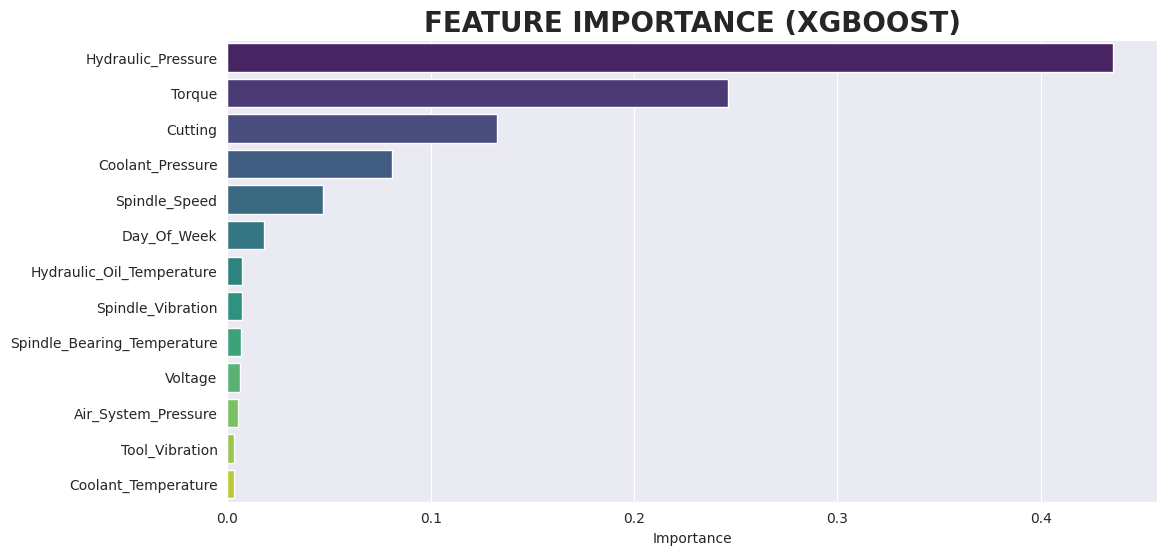

In [54]:
# Feature importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.ylabel("")
plt.title("Feature Importance (XGBoost)".upper(), weight='bold', fontsize=20)
plt.show()


In [55]:
# xgboost_tree 
#plt.figure(figsize=(32, 16), dpi=300)
#xgb.plot_tree(xgb_classifier, num_trees=0, rankdir='LR')
#plt.axis('off')
#plt.savefig("xgboost_tree.png", bbox_inches="tight", dpi=300)  # Save as PNG
#plt.show()

## Explainability with SHAP

SHAP (SHapley Additive Explanations) provides a more detailed view of how each feature influences individual predictions. Unlike XGBoost’s feature importance, which reflects how often a feature is used in splits, SHAP measures a feature’s actual impact on predictions. As a result, the ranking of features may differ between the two methods. Higher-ranked features (top) have a greater overall impact on shifting model predictions.

SHAP identifies `Torque, Cutting, Coolant Pressure, and Hydraulic Pressure` as the most impactful features for predictions. This is likely due to stronger nonlinear interactions and higher variance, leading to a greater effect on individual predictions. While Hydraulic Pressure was the most used feature in tree splits, it may not always have the highest impact on every prediction, which could explain why it ranks lower in SHAP analysis.

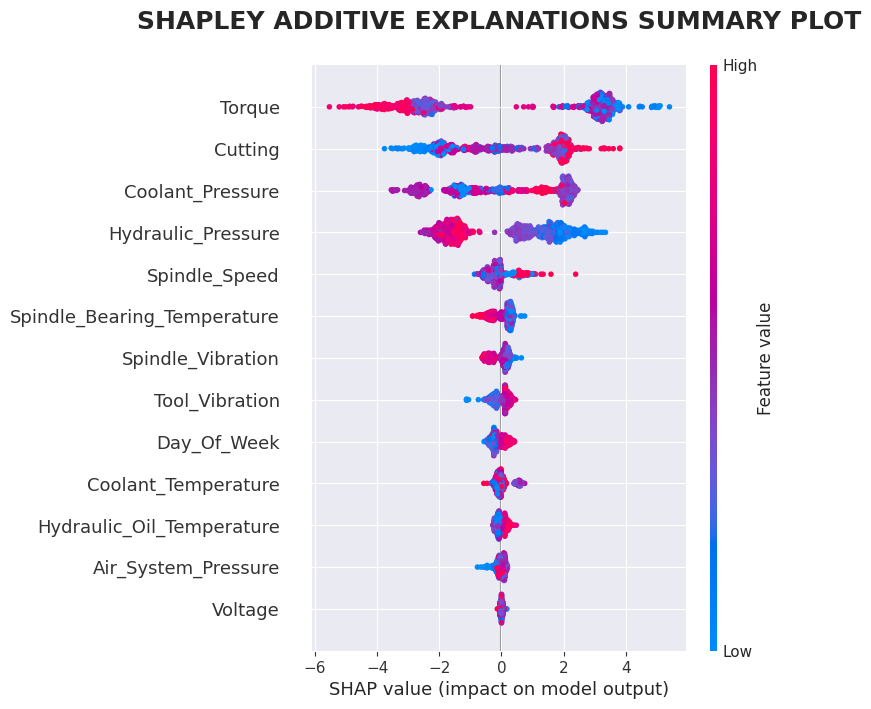

In [56]:
# Ensure SHAP explains probabilities instead of log-odds
import shap

index = 4 #row_to_show
data_for_prediction = X_test.iloc[index] 
data_for_prediction_array = data_for_prediction.values.reshape(1, -1)
preds = xgb_classifier.predict_proba(data_for_prediction_array)

explainer = shap.TreeExplainer(xgb_classifier, feature_perturbation="interventional", model_output="raw")
shap_values = explainer.shap_values(X_test, check_additivity=False)

plt.figure(figsize=(8, 3))  # Define size before SHAP plot
shap.summary_plot(shap_values, X_test, show=False)  # Prevent auto-display
plt.title("SHapley Additive Explanations Summary Plot\n".upper(), weight='bold', fontsize=18)
plt.show()

The observation below is being explained with SHAP in the following sections.

In [57]:
# Instance being explained
index = 4
instance = X_test.iloc[index]
instance['Downtime'] = y_test[index][0]

print("Observation to be explained:".upper())
instance.to_frame().transpose()

OBSERVATION TO BE EXPLAINED:


,Hydraulic_Pressure,Coolant_Pressure,Air_System_Pressure,Coolant_Temperature,Hydraulic_Oil_Temperature,Spindle_Bearing_Temperature,Spindle_Vibration,Tool_Vibration,Spindle_Speed,Voltage,Torque,Cutting,Day_Of_Week,Downtime
694,77.59,4.258446,5.692249,18.5,49.7,37.6,1.106,17.026,17076.0,417.0,27.957484,3.67,1.0,1.0


In [58]:
# Check if SHAP is Explaining Probabilities

# Get model predicted probability
pred_proba = xgb_classifier.predict_proba(X_test)[:, 1][index]

# Compute SHAP sum
shap_sum = explainer.expected_value + shap_values[index].sum()

# Convert log-odds to probability
shap_proba = 1 / (1 + np.exp(-shap_sum))

# If shap_proba ≈ pred_proba, then SHAP is still explaining log-odds, not probabilities.
#print("Predicted Probability:", pred_proba)
#print("SHAP Computed Probability:", shap_proba)
#SHAP is already explaining probabilities.

### SHAP Explanation for a Specific Observation  

The SHAP analysis for this observation reveals that the most influential features strongly pushed the model toward predicting downtime with extreme confidence (99.97%).  

Key contributors to this high probability include:  
- Torque (27.96)  
- Cutting (3.67)  
- Coolant Pressure (4.258)  
- Hydraulic Pressure (77.59)  
- Coolant Temperature (18.5)  

These features significantly increased the probability of downtime in this instance.  

On average, the model predicts a low probability of downtime (~2%), as indicated by the base value. However, in this case, the SHAP values of these critical features elevated the model’s output to f(x) = 8.28, leading to a final predicted probability of 99.97%—indicating near certainty of downtime.  

This analysis confirms that the model effectively identifies high-risk patterns, which can be used to trigger preventive actions when these feature values reach critical levels.  



In [59]:
# SHAP force plot results
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[index], X_test.iloc[index])

### Decision Plot Analysis  
The decision plot visually tracks how a machine failure prediction is made step by step. It highlights which features increase or decrease the risk of downtime and where the decision stabilizes.  

- X-axis: Represents the accumulation of SHAP values, moving from left (base value) to right (final prediction).  
- Y-axis: Each line represents a feature's contribution, ordered by importance (top → most impactful).  

Key Insights from SHAP Analysis:
- Torque, Cutting, and Coolant Pressure were the strongest contributors to predicting downtime.  
- Some features (e.g., Air System Pressure, Coolant Temperature) attempted to push the prediction toward "no downtime" but their influence was weaker.  
- Other features (e.g., Voltage, Spindle Speed, Hydraulic Pressure) had high values but did not play a significant role in this specific prediction.  
- The final model output \( f(x) = 8.28 \) translates to an extremely high downtime probability (99.97%), confirming the model's confidence in its prediction.  

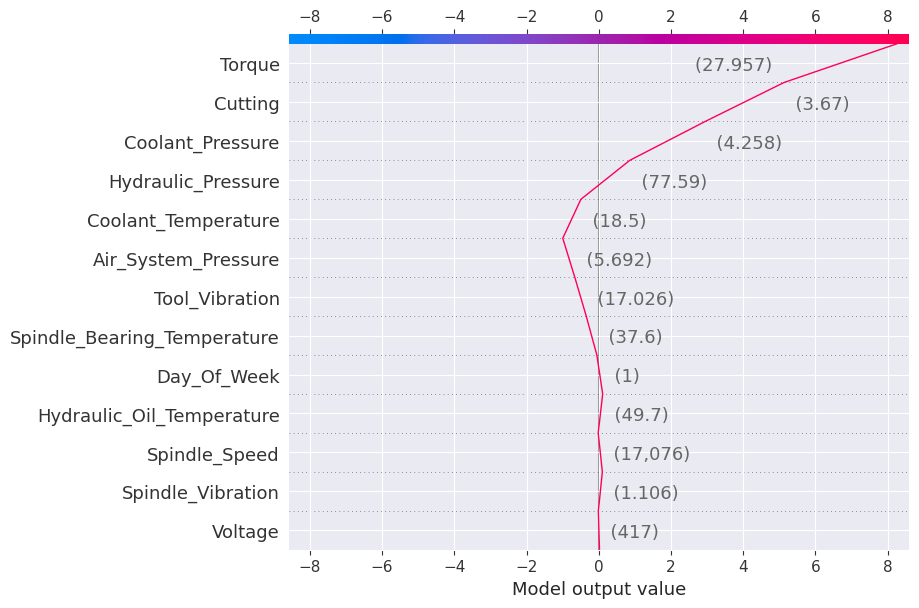

In [60]:
# Decision plot (tracks how a decision is made)
shap.decision_plot(explainer.expected_value, shap_values[index], X_test.iloc[index])

## Deployment and Predictive Maintainance
The goal is to predict machine downtime based on sensor data, so operators can take action before a failure occurs. Most real-world solutions involve a mix of ML classification, anomaly detection, and real-time monitoring.

The XGBoost classification model achieved high accuracy and a strong F1-score, indicating its effectiveness in predicting machine downtime based on the available features. However, the dataset only contains date information without precise timestamps, which limits the ability to capture short-term variations and sudden changes in sensor readings. Without timestamp granularity, it becomes challenging to analyze sequential patterns or detect anomalies that occur within a single day.  

**Capabilities of the Current Model:**

- High accuracy and PR-AUC score in classifying downtime occurrences.  
- Identifies key features influencing machine failure, such as Hydraulic Pressure, Torque, and Cutting.  
- Provides interpretable feature importance for failure diagnostics.

**Future Steps:**

- Incorporate Timestamp Data – Collect and integrate hourly or minute-level timestamps to enhance temporal analysis.  
- Apply Time-Series Feature Engineering – Create lag variables and rolling statistics (e.g., moving averages) to better model gradual degradation.  
- Explore Anomaly Detection – Complement XGBoost with real-time monitoring models (e.g., Isolation Forest, LSTMs) to detect unexpected patterns.  
- Implement Predictive Maintenance Pipeline – Deploy the model in a real-time system using Kafka, Grafana, or IoT dashboards to trigger proactive alerts.

### Monitoring:  

Monitoring is crucial to ensure their continued effectiveness. After putting the model in production, it should allow automatically log actual downtimes from machine sensors, address the challenges of obtaining true labels, identifying incorrect/missed preemptive actions and allow operators to override labels when they suspect a misclassification and monitoring Drifts. In general the steps are:

- Short-term: Monitor precision-recall tradeoff and collect operator feedback.
- Mid-term: Watch for drift in features and labels, comparing pre/post-deployment performance.
- Long-term: Develop a model retraining strategy based on performance decline & data drifts. 

## Predictive Maintenance Financial Simulation

This simulation evaluates the economic impact of replacing a reactive (corrective) maintenance strategy with a predictive maintenance strategy powered by an XGBoost classifier.

### Test Set Description

The financial evaluation is based on a held-out test set containing 136 distinct operational days.The model produced the following confusion matrix:

- TN (True Negatives): 368
- FP (False Positives): 0
- FN (False Negatives): 1
- TP (True Positives): 381
  
The corresponding F1-score is 99%, indicating an almost perfect balance between precision and recall. The model missed only one failure and generated no false alarms during the test period. This extremely high predictive performance strongly influences the financial results.

### Monthly Normalization and Event Estimation

To estimate economic impact on a monthly scale, the observed events were normalized using: 

scaling factor = 30 / 136

From this, the following monthly estimates were derived:

- Monthly Failures (Reactive Scenario): (TP + FN) * scaling factor
- Monthly Predictive Interventions: (TP + FP)  * scaling factor
- Monthly Missed Failures: (FN  * scaling factor)

This assumes that the failure rate observed during the test period is representative of a typical operational month.

### Cost Assumptions

The simulation allows variation in:

- Revenue impact per hour (USD)
- Monthly ML system operational cost (excluding development investment)
- Average downtime duration (hours)
- Average predictive maintenance duration (hours)
- Downtime operational cost per hour
- Predictive maintenance operational cost per hour

Each event cost is calculated as:

Event Cost = Duration * (Production Cost per Hour + Operational Cost per Hour)


So, initially it was obtained from the test set the monthly Failures (Reactive Scenario), monthly Predictive Interventions and monthly missed Failures and monthly False Positives. Then calculated the cost per event, considering the duration and impact in production and operational cost per hour. Finally compared the cost * Monthly Failures for Reactive Strategy. For Predictive maintenance incurs the Maintenance cost for every predicted failure (TP + FP), Downtime cost for missed failures (FN) and Monthly model operational cost. 

The Net Financial Benefit was calulated subtracting the redictive Total Cost from Baseline Cost. And the ROI dividing the finanction benefit (net profit) by the cost of the model. 

In general, the results show that based on the observations of the test set, it is very recomended the usage of predictive downtime in most scenarios, since the ROI is quite hight. The ROI appears inflated primarily due to near-perfect predictive performance and high volumes of failure events, which makes it very financially interesting in some cost scenarios.

A full-scale industrial implementation would require a broader cost model to provide a more realistic return projection.

## Predictive Maintenance Financial Simulation

This simulation below evaluates the economic impact of replacing a reactive (corrective) maintenance strategy with a predictive maintenance strategy powered by an XGBoost classifier. The financial assessment is based on a held-out test set containing 136 distinct operational days. Over this period, the model produced the following results: 368 true negatives, 0 false positives, 1 false negative, and 381 true positives. This corresponds to an F1-score of 99%, indicating an almost perfect balance between precision and recall. The model missed only one failure and generated no false alarms, which strongly influences the financial outcome of the analysis.

To estimate monthly impact, the observed events in the test set were normalized to a 30-day period using a scaling factor of 30/136. From this normalization, monthly failures under the reactive scenario were calculated as (TP + FN), while monthly predictive interventions were calculated as (TP + FP), and monthly missed failures as FN. This approach assumes that the failure rate observed during the test period is representative of a typical month of operations, which is an important modeling assumption.

Event costs were calculated by multiplying the event duration (in hours) by the sum of production revenue loss per hour and operational maintenance cost per hour. 

- **Under the reactive strategy**, every failure results in unplanned downtime, so the total monthly cost equals the number of monthly failures multiplied by the downtime cost per event.
  
- **Under the predictive strategy**, costs include preventive maintenance for every predicted failure (true positives and false positives), downtime costs for missed failures (false negatives), and the monthly operational cost of the machine learning system.

The net financial benefit is computed as the difference between the reactive cost and the predictive total cost, while ROI is defined as net profit divided by the model’s monthly cost.

Logically, the strategy comparison is internally consistent: both approaches are evaluated under the same observed failure volume, events are properly normalized to a common time horizon, and costs are calculated using the same structural assumptions. Within this approach, the predictive strategy proves economically viable across most tested cost scenarios. However, the high ROI observed in the simulation must be interpreted carefully.

The reported ROI appears elevated primarily because of three factors: 
- the near-perfect predictive performance (99% F1-score with virtually no missed failures or false alarms),
- the relatively high frequency of failure events observed in the dataset (which amplifies cumulative savings when scaled monthly), 
- the comparatively low assumed operational cost of the model. Even small per-event cost differences accumulate significantly when approximately 84 failures per month are considered.

Additional conclusions can be drawn beyond the financial comparison: 

- the economic attractiveness of the predictive strategy is highly sensitive to model performance;
- increases in false negatives would rapidly raise downtime costs, while increases in false positives would inflate unnecessary maintenance expenses.
- the results depend heavily on the assumption that the test-set failure frequency reflects long-term operational reality. 
- the model cost considered in the simulation includes only monthly operational expenses and excludes development, infrastructure, integration, retraining, and organizational change costs. Incorporating these elements would likely reduce short-term ROI.
- while the model focuses on direct financial impact, predictive maintenance may also generate indirect benefits such as improved production stability, reduced operational volatility, better planning capability, and lower stress on maintenance teams—effects not captured in the current cost formulation.

In conclusion, based on the financial logic of the simulation, predictive maintenance is economically attractive is valid under the stated assumptions.

However, the magnitude of the ROI should be interpreted as an optimistic scenario driven by extremely strong predictive performance and simplified cost assumptions. A full industrial deployment would require a broader cost model and sensitivity analysis to produce a more conservative and realistic investment evaluation.

Use the widget below to experiment with different assumptions and evaluate alternative financial scenarios.

In [61]:
# Widtget Functions
import ipywidgets as widgets
from ipywidgets.embed import embed_minimal_html
from IPython.display import display, IFrame

# Confusion matrix from test set (defined previously)
conf_matrix = xgb_confusion_matrix

# Number of distinct days present in the test dataset
distinct_days_test = X_test_with_dates['Day'].nunique()

# ============================================================
# Financial Utilities
# ============================================================

def calculate_event_cost(hours: float,
                         production_cost_per_hour: float,
                         operational_cost_per_hour: float) -> float:
    """
    Calculates total cost of a maintenance event.
    """
    return hours * (production_cost_per_hour + operational_cost_per_hour)


def simulate_financial_impact(conf_matrix,
                              distinct_days_test: int,
                              production_cost_per_hour: float,
                              cost_model: float,
                              downtime_hours: float,
                              predictive_hours: float,
                              downtime_operational_cost: float,
                              predictive_operational_cost: float) -> dict:
    """
    Compares Reactive (Corrective) vs Predictive Maintenance.

    - Normalizes test-set events to a 30-day month
    - Calculates baseline (all failures → downtime)
    - Calculates predictive scenario (TP+FP maintenance, FN downtime)
    """

    # ------------------------------
    # Confusion Matrix
    # ------------------------------
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    # ------------------------------
    # Monthly Normalization
    # ------------------------------
    scaling_factor = 30 / distinct_days_test

    monthly_failures = (TP + FN) * scaling_factor
    monthly_predictive_actions = (TP + FP) * scaling_factor
    monthly_false_negatives = FN * scaling_factor

    # ------------------------------
    # Event Costs
    # ------------------------------
    downtime_cost = calculate_event_cost(
        downtime_hours,
        production_cost_per_hour,
        downtime_operational_cost
    )

    predictive_cost = calculate_event_cost(
        predictive_hours,
        production_cost_per_hour,
        predictive_operational_cost
    )

    # ------------------------------
    # Reactive Strategy (Baseline)
    # ------------------------------
    baseline_cost = monthly_failures * downtime_cost

    # ------------------------------
    # Predictive Strategy
    # ------------------------------
    predictive_total_cost = (
        monthly_predictive_actions * predictive_cost +
        monthly_false_negatives * downtime_cost +
        cost_model
    )

    # ------------------------------
    # Financial Impact
    # ------------------------------
    net_profit = baseline_cost - predictive_total_cost
    roi = net_profit / cost_model if cost_model > 0 else 0

    return {
        "confusion_matrix": {
            "TN": TN, "FP": FP,
            "FN": FN, "TP": TP
        },
        "monthly_events": {
            "failures": monthly_failures,
            "predictive_actions": monthly_predictive_actions,
            "false_negatives": monthly_false_negatives
        },
        "costs": {
            "downtime_cost": downtime_cost,
            "predictive_cost": predictive_cost
        },
        "baseline_cost": baseline_cost,
        "predictive_total_cost": predictive_total_cost,
        "net_profit": net_profit,
        "roi": roi,
        "is_viable": net_profit > 0
    }


def display_financial_results(results: dict):
    """
    Displays Reactive vs Predictive comparison.
    """

    cm = results["confusion_matrix"]
    monthly = results["monthly_events"]
    costs = results["costs"]

    print("===== REACTIVE vs PREDICTIVE MAINTENANCE =====\n")

    print(f"Confusion Matrix → TN: {cm['TN']}, FP: {cm['FP']}, "
          f"FN: {cm['FN']}, TP: {cm['TP']}")
    print(f"Distinct test-set days: {distinct_days_test}\n")

    print("---- Monthly Normalized Events ----")
    print(f"Estimated Failures (Reactive): {monthly['failures']:.2f}")
    print(f"Predictive Interventions: {monthly['predictive_actions']:.2f}")
    print(f"False Negatives (Missed Failures): {monthly['false_negatives']:.2f}\n")

    print("---- Cost per Event ----")
    print(f"Downtime Cost: ${costs['downtime_cost']:,.0f}")
    print(f"Predictive Maintenance Cost: ${costs['predictive_cost']:,.0f}\n")

    print("---- Financial Comparison ----")
    print(f"Reactive Monthly Cost: ${results['baseline_cost']:,.0f}")
    print(f"Predictive Monthly Cost: ${results['predictive_total_cost']:,.0f}")
    print(f"Net Monthly Benefit: ${results['net_profit']:,.0f}")
    print(f"ROI (vs Model Cost): {results['roi']*100:.2f}%")

    if results["is_viable"]:
        print("\n✅ PREDICTIVE STRATEGY IS ECONOMICALLY VIABLE")
    else:
        print("\n❌ PREDICTIVE STRATEGY IS NOT ECONOMICALLY VIABLE")

In [62]:
# Unit tests
def test_net_profit_positive():
    
    results = simulate_financial_impact(
        xgb_confusion_matrix,
        distinct_days_test,
        production_cost_per_hour=5000,
        cost_model=5000,
        downtime_hours=5,
        predictive_hours=4,
        downtime_operational_cost=950,
        predictive_operational_cost=750
    )
    
    assert results["net_profit"] > 0
    assert results["is_viable"]  == True

def test_net_profit_negative2():
    
    results = simulate_financial_impact(
        xgb_confusion_matrix,
        distinct_days_test,
        production_cost_per_hour=1000,
        cost_model=1000,
        downtime_hours=1,
        predictive_hours=1,
        downtime_operational_cost=50,
        predictive_operational_cost=50
    )
    
    assert results["net_profit"] < 0
    assert results["is_viable"]  == False



def test_net_profit_negative():
    
    # Force model to be expensive and low impact
    results = simulate_financial_impact(
        xgb_confusion_matrix,
        distinct_days_test,
        production_cost_per_hour=500,
        cost_model=500000,  # extremely high model cost
        downtime_hours=1,
        predictive_hours=1,
        downtime_operational_cost=50,
        predictive_operational_cost=50
    )
    
    assert results["net_profit"] < 0
    assert results["is_viable"] == False

test_net_profit_positive()
test_net_profit_negative()
test_net_profit_negative2()

In [63]:
# Widget Configuration
print("Widgets interativos não são renderizados na visualização pública.")

style = {'description_width': '420px'}
layout = widgets.Layout(width='70%')

production_cost_slider = widgets.IntSlider(
    min=1000, max=20000, step=100, value=1000,
    description='Revenue Impact per Hour (USD)',
    style=style, layout=layout
)

model_cost_slider = widgets.IntSlider(
    min=1000, max=20000, step=1000, value=1000,
    description='ML System Cost per Month (USD)',
    style=style, layout=layout
)

downtime_hours_slider = widgets.FloatSlider(
    min=1, max=12, step=0.5, value=1,
    description='Downtime Duration (Hours)',
    style=style, layout=layout
)

predictive_hours_slider = widgets.FloatSlider(
    min=1, max=12, step=0.5, value=1,
    description='Predictive Maintenance Duration (Hours)',
    style=style, layout=layout
)

downtime_cost_slider = widgets.IntSlider(
    min=50, max=5000, step=50, value=100,
    description='Downtime Operational Cost/Hour (USD)',
    style=style, layout=layout
)

predictive_cost_slider = widgets.IntSlider(
    min=50, max=5000, step=50, value=50,
    description='Predictive Maintenance Cost/Hour (USD)',
    style=style, layout=layout
)

ui = widgets.VBox([
    production_cost_slider,
    model_cost_slider,
    downtime_hours_slider,
    predictive_hours_slider,
    downtime_cost_slider,
    predictive_cost_slider
])

display(ui)

# ============================================================
# Interactive Output
# ============================================================

output = widgets.Output()
display(output)

def wrapped_simulation(**kwargs):
    with output:
        output.clear_output()
        results = simulate_financial_impact(**kwargs)
        display_financial_results(results)

controls = widgets.interactive_output(
    wrapped_simulation,
    {
        'production_cost_per_hour': production_cost_slider,
        'cost_model': model_cost_slider,
        'downtime_hours': downtime_hours_slider,
        'predictive_hours': predictive_hours_slider,
        'downtime_operational_cost': downtime_cost_slider,
        'predictive_operational_cost': predictive_cost_slider,
        'conf_matrix': widgets.fixed(conf_matrix),
        'distinct_days_test': widgets.fixed(distinct_days_test)
    }
)

display(controls)

Widgets interativos não são renderizados na visualização pública.


Output()

Output()

## Conclusion

The dataset provided a good foundation for predicting downtime, enabling the identification of key patterns and the most influential features contributing to machine failures.

The XGBoost model achieved high accuracy and a strong F1-score, both of 99.99%, effectively predicting machine downtime based on sensor data to help operators take preventive action before failures occur. It not only demonstrated effectiveness in predicting downtime but also identified key contributing factors such as Hydraulic Pressure, Torque, and Cutting. The data were neither scaled nor normalized, and further improvements could be achieved through hyperparameter tuning and feature selection to enhance model performance.

Predictive maintenance could be further improved by incorporating timestamp data, time-series feature engineering, and anomaly detection to enhance early failure detection. Additionally, deploying a real-time monitoring system using tools like Kafka, Grafana, or IoT dashboards would enable proactive intervention. This should be complemented by continuous monitoring to track model drift, validate predictions, and refine retraining strategies. More specific recommendations on monitoring and data preprocessing would require deeper business insights, particularly regarding operational constraints, sensor reliability, and failure labeling processes.

Further investigation is needed to address sensor reliability concerns and data inconsistencies. Sensor errors, missing values, and potential correlations between sensors and operational factors should be analyzed to improve data accuracy. In this analysis, extreme values far beyond the upper whiskers and negative values were imputed with the median, assuming they were erroneous. However, distinguishing between true sensor errors and meaningful rare events requires validation to ensure no critical failure patterns are overlooked. To improve the data collection process, methodologies and strategies used should be evaluated to ensure consistency and reliability across different sensor types and operational conditions.

The simulation, considering financial factors and economic viability, indicates that based on the 136-day test set and a 99% F1-score XGBoost model, predictive maintenance is financially superior to reactive maintenance under the tested assumptions. After monthly normalization, the reduction in unplanned downtime generates positive net benefit in most cost scenarios. However, the high ROI should be interpreted cautiously, as it reflects near-perfect predictive performance, relatively high observed failure frequency, and simplified cost assumptions.

To improve realism, future versions of the simulation should incorporate an actionable lead time assumption (minimum hours required to act before downtime), a defined operational probability threshold for triggering maintenance, partial severity reduction (since not all failures are fully avoidable), and operational constraints such as intervention limits. Additionally, including a scheduled maintenance policy (e.g., maintenance every three days) would allow a full comparison between corrective, predictive, and preventive strategies. Expanding the cost structure to include development, integration, and long-term operational expenses would also provide a more conservative and executive-ready financial assessment.

In conclusion, based on the financial logic of the simulation, predictive maintenance is economically attractive is valid under the stated assumptions.

_Thanks for reading!_